In [1]:
import os
import os.path
import sys
import re
import glob
from sys import platform
from shutil import copyfile
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from scipy.ndimage import gaussian_filter,rotate
from tifffile import imread, imwrite, TiffFile
from PIL import Image
import copy
import cv2
import warnings
import timeit
import pickle
from matplotlib.backends.backend_pdf import PdfPages
import sled_general_tools
import sled_image_tools
import sled_stat_tools
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42
def imshow_cleanup(ax):
    ax.axes.xaxis.set_visible(False)
    ax.axes.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_facecolor('none')
    return ax

In [2]:
filePath = "/export/disk1/pooledData/ReLOAD/rhizome_1p9V_50by50um/"
savePath = "/export/disk1/pooledData/ReLOAD/rhizome/"

In [3]:
allFiles = []
for (dirpath, dirnames, filenames) in os.walk(filePath):
    allFiles.extend(filenames)
    break
sled_general_tools.print_table(allFiles, ncols = 5, max_width = 400, indices = True)

+-----------------------------------------+-----------------------------------------+-----------------------------------------+-----------------------------------------+-----------------------------------------+
| 0: rhizome_100pow_1p9V_00037_00001.tif  | 16: rhizome_60pow_1p9V_00007_00001.tif  | 32: rhizome_60pow_1p9V_00015_00001.tif  | 48: rhizome_60pow_1p9V_00023_00001.tif  | 64: rhizome_60pow_1p9V_00031_00001.tif  |
| 1: rhizome_100pow_1p9V_00001_00001.tif  | 17: rhizome_100pow_1p9V_00009_00001.tif | 33: rhizome_100pow_1p9V_00017_00001.tif | 49: rhizome_100pow_1p9V_00025_00001.tif | 65: rhizome_100pow_1p9V_00033_00001.tif |
| 2: rhizome_100pow_1p9V_00036_00001.tif  | 18: rhizome_60pow_1p9V_00008_00001.tif  | 34: rhizome_60pow_1p9V_00016_00001.tif  | 50: rhizome_60pow_1p9V_00024_00001.tif  | 66: rhizome_60pow_1p9V_00032_00001.tif  |
| 3: rhizome_100pow_1p9V_00002_00001.tif  | 19: rhizome_100pow_1p9V_00010_00001.tif | 35: rhizome_100pow_1p9V_00018_00001.tif | 51: rhizome_100pow_1p9V_

In [4]:
z_prefix = []
for f in allFiles:
    z_prefix.append(f[0:-16])
z_prefix.sort()
z_prefix = list(set(z_prefix))
sled_general_tools.print_table(z_prefix, ncols = 3, max_width = 400, indices = True)

+------------------------+-----------------------+---+
| 0: rhizome_100pow_1p9V | 1: rhizome_60pow_1p9V |   |
+------------------------+-----------------------+---+


In [5]:
fileName = allFiles[0]
print(fileName)
_,_,_,_,fsize=sled_general_tools.retrieve_file_info(os.path.join(filePath,fileName))
print(fsize)
tiff = TiffFile(os.path.join(filePath,fileName))
width = tiff.pages[0].imagewidth
height = tiff.pages[0].imagelength
dtype = tiff.pages[0].dtype
nframes = int(len(tiff.pages))
data=imread(os.path.join(filePath,fileName))
print(data.shape)

rhizome_100pow_1p9V_00037_00001.tif
301297632
(10000, 190, 73)


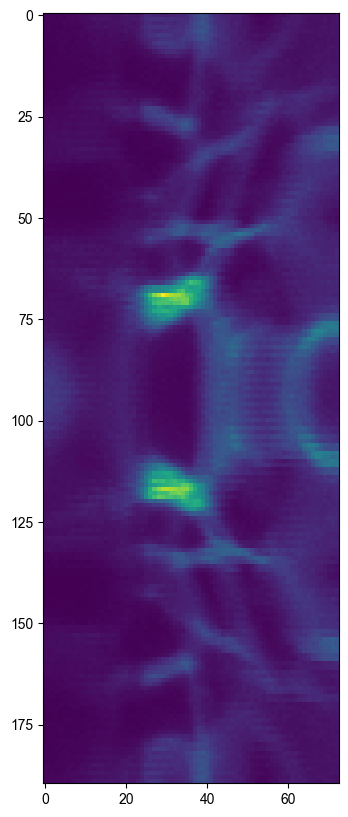

In [6]:
data_meanProj = np.nanmean(data[5000:5500,:,:],axis=0)
plt.figure(figsize = (10,10))
plt.imshow(data_meanProj)

In [7]:
zData = {}
z = -1

# saveName = "rhizome_60pow_1p9V"
# z+=1
# zData[z] = {}
# zData[z]['prefix'] = 'rhizome_60pow_1p9V'
# zData[z]['zPos'] = 0


saveName = "rhizome_100pow_1p9V"
z+=1
zData[z] = {}
zData[z]['prefix'] = 'rhizome_100pow_1p9V'
zData[z]['zPos'] = 0


In [8]:
fileSizeFlag = 300000000
nFramesFlag = 10000
for z in range(len(zData)):
    zData[z]['files'] = [file for file in allFiles if re.search(r''+zData[z]['prefix']+'.*', file)]
    zData[z]['nfiles'] = len(zData[z]['files'])
    zData[z]['ngood_files'] = 0
    zData[z]['fileInfo'] = {}
    zData[z]['fileSizes'] = []
    zData[z]['fileIndices'] = []
    tempList = []
    for i,file in enumerate(zData[z]['files']):
        zData[z]['fileInfo'][i] = {}
        zData[z]['fileInfo'][i]['createdTime'], zData[z]['fileInfo'][i]['createdDateTimeFormatted'], _, _, zData[z]['fileInfo'][i]['filesize'] = \
            sled_general_tools.retrieve_file_info(os.path.join(filePath,file))
        tiff = TiffFile(os.path.join(filePath,fileName))
        zData[z]['fileInfo'][i]['width'] = tiff.pages[0].imagewidth
        zData[z]['fileInfo'][i]['height'] = tiff.pages[0].imagelength
        zData[z]['fileInfo'][i]['dtype'] = tiff.pages[0].dtype
        zData[z]['fileInfo'][i]['nframes'] = int(len(tiff.pages))

        
        zData[z]['fileSizes'].append(zData[z]['fileInfo'][i]['filesize'])
        if zData[z]['fileInfo'][i]['filesize'] > fileSizeFlag and zData[z]['fileInfo'][i]['nframes'] >= nFramesFlag:
            zData[z]['fileIndices'].append(i)
            flag = ' '
            zData[z]['ngood_files']+=1
        else:
            flag = 'x'
            
        tempList.append(flag+" - "+file+" "+str(zData[z]['fileInfo'][i]['nframes'])+"x"+str(zData[z]['fileInfo'][i]['height'])+"x"+str(zData[z]['fileInfo'][i]['width'])+" fSize:"+str(zData[z]['fileInfo'][i]['filesize']))
    print("Z"+str(z)+" "+str(zData[z]['zPos'])+" "+zData[z]['prefix']+" nFiles = "+str(zData[z]['ngood_files'])+"/"+str(zData[z]['nfiles']))
    sled_general_tools.print_table(tempList, ncols = 3, max_width = 400, indices = True)


Z0 0 rhizome_100pow_1p9V nFiles = 38/40
+--------------------------------------------------------------------------+--------------------------------------------------------------------------+--------------------------------------------------------------------------+
| 0:   - rhizome_100pow_1p9V_00037_00001.tif 10000x190x73 fSize:301297632  | 14:   - rhizome_100pow_1p9V_00010_00001.tif 10000x190x73 fSize:301297632 | 28:   - rhizome_100pow_1p9V_00024_00001.tif 10000x190x73 fSize:301297632 |
| 1:   - rhizome_100pow_1p9V_00001_00001.tif 10000x190x73 fSize:301297632  | 15:   - rhizome_100pow_1p9V_00011_00001.tif 10000x190x73 fSize:301297632 | 29:   - rhizome_100pow_1p9V_00025_00001.tif 10000x190x73 fSize:301297632 |
| 2:   - rhizome_100pow_1p9V_00036_00001.tif 10000x190x73 fSize:301297632  | 16:   - rhizome_100pow_1p9V_00012_00001.tif 10000x190x73 fSize:301297632 | 30:   - rhizome_100pow_1p9V_00026_00001.tif 10000x190x73 fSize:301297632 |
| 3:   - rhizome_100pow_1p9V_00002_00001.tif 10000x1

In [312]:
nFiles2Load = 1
loadDirection = -1
for z in range(len(zData)):
    print("Z"+str(z)+" "+str(zData[z]['zPos'])+" "+zData[z]['prefix'])
    if loadDirection == -1:
        zData[z]['loadIndices'] = zData[z]['fileIndices'][-1*nFiles2Load:]
    zData[z]['data'] = {}
    for i in zData[z]['loadIndices']:
        print("Loading: "+zData[z]['files'][i],end='...')
        zData[z]['data'][i] = {}
        zData[z]['data'][i]['rawData'] = imread(os.path.join(filePath,zData[z]['files'][i])).astype('float32')
        print("Finished!",flush=True)

Z0 0 rhizome_100pow_1p9V
Loading: rhizome_100pow_1p9V_00035_00001.tif...Finished!


In [313]:
nFrames2Scan = 200
histRange = [-50,700]
binSize = 1
scanDirection = 1
for z in range(len(zData)):
    print("Stats Z"+str(z)+" "+str(zData[z]['zPos'])+" "+zData[z]['prefix'],end='')
    for i in zData[z]['loadIndices']:
        print('',end='.')
        if scanDirection == 1:
            zData[z]['data'][i]['scanFrames'] = list(range(0,nFrames2Scan))
        zData[z]['data'][i]['stats'] = sled_stat_tools.summary_stats(zData[z]['data'][i]['rawData'][zData[z]['data'][i]['scanFrames'],:,:],nBins=0,binWidth=binSize,temp_minVal=histRange[0],temp_maxVal=histRange[1],\
            calcHist=True,verbose=False, allow_overages = False, splitZeroBin = False, \
            calc_hist_log10 = True, calc_cumulative_hist = False, calc_norm_hist = False, calc_cumulative_freq = False, calc_pdf = False, 
            save_input = False, force_dType=False, dType='float32', exclude_NaNs = False, warningsOn = True)
        zData[z]['data'][i]['meanVals'] = []
        for n in range(zData[z]['data'][i]['rawData'].shape[0]):
            zData[z]['data'][i]['meanVals'].append(np.nanmean(np.ndarray.flatten(zData[z]['data'][i]['rawData'][n,:,:])))
    print("Finished!")

Stats Z0 0 rhizome_100pow_1p9V.Finished!


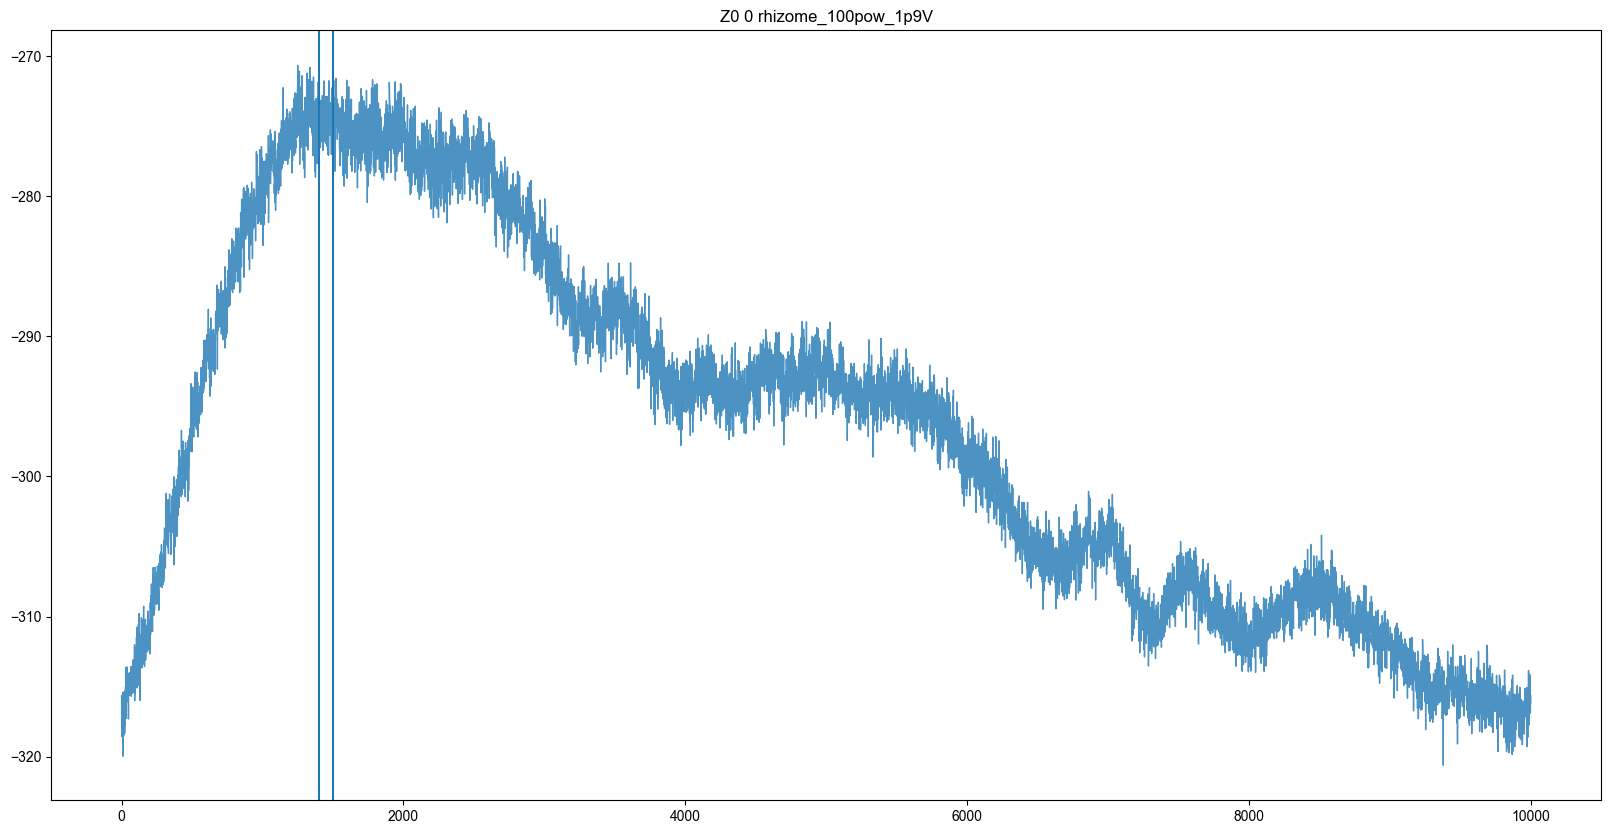

In [321]:
shiftVal = 10
for z in range(len(zData)):
    plt.figure(figsize = (20,10))
    plt.title("Z"+str(z)+" "+str(zData[z]['zPos'])+" "+zData[z]['prefix'])
    for i in zData[z]['loadIndices']:
        plt.plot(np.array(zData[z]['data'][i]['meanVals'])-shiftVal*i,lw = 1,alpha=0.8)
    plt.axvline(1400)
    plt.axvline(1500)
    plt.show()


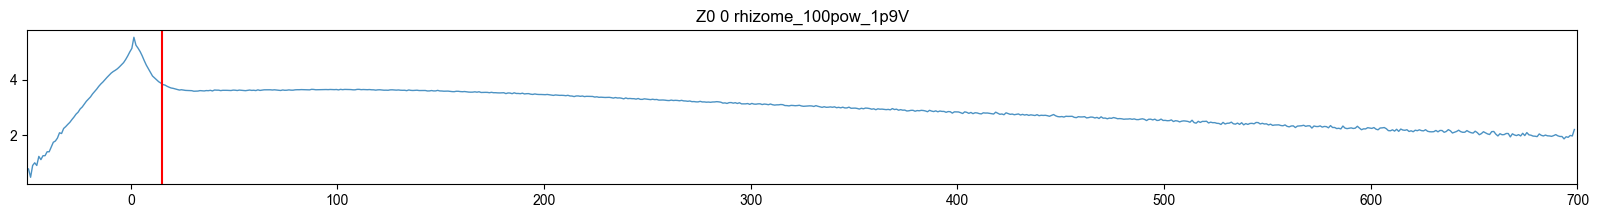

In [315]:
noiseCutoff = 15
for z in range(len(zData)):
    plt.figure(figsize = (20,2))
    plt.title("Z"+str(z)+" "+str(zData[z]['zPos'])+" "+zData[z]['prefix'])
    plt.xlim(histRange)
    for i in zData[z]['loadIndices']:
        plt.plot(zData[z]['data'][i]['stats']['binCenters'],zData[z]['data'][i]['stats']['hist_log10'],lw = 1,alpha=0.8)
    plt.axvline(noiseCutoff,color = (1,0,0),lw = 1.5)
    plt.show()

In [316]:
nFrames2Merge = 10000
mergeDirection = 1
mergeMethod = 'mean'
if mergeMethod == 'sum':
    mergeLabel = str(nFiles2Load)+"fileSum"
elif mergeMethod == 'mean':
    mergeLabel = str(nFiles2Load)+"fileAvg"
for z in range(len(zData)):
    print("Merging Z"+str(z)+" "+str(zData[z]['zPos'])+" "+zData[z]['prefix'],end='')
    if mergeDirection == 1:
        zData[z]['mergeFrames'] = list(range(0,nFrames2Merge))
    i = zData[z]['loadIndices'][0] 
    zData[z]['mergeData'] = np.zeros((nFrames2Merge,zData[z]['fileInfo'][i]['height'],zData[z]['fileInfo'][i]['width']),dtype='float32')
    for i in zData[z]['loadIndices']:
        print('',end='.')
        for n in range(zData[z]['data'][i]['rawData'].shape[0]):
            tempImg = copy.deepcopy(zData[z]['data'][i]['rawData'][n,:,:])
            tempImg[tempImg<=noiseCutoff] = 0
            if mergeMethod == 'sum' or mergeMethod == 'mean':
                zData[z]['mergeData'][n,:,:] = zData[z]['mergeData'][n,:,:] + tempImg
    if mergeMethod == 'mean':
        zData[z]['mergeData'] = zData[z]['mergeData'] / len(zData[z]['loadIndices'])
    zData[z]['mergeDataProjs'] = {}
    zData[z]['mergeDataProjs']['mean'] = np.nanmean(zData[z]['mergeData'],axis=0)
    zData[z]['mergeDataProjs']['sum'] = np.sum(zData[z]['mergeData'],axis=0)
    print("Finished!")

Merging Z0 0 rhizome_100pow_1p9V.Finished!


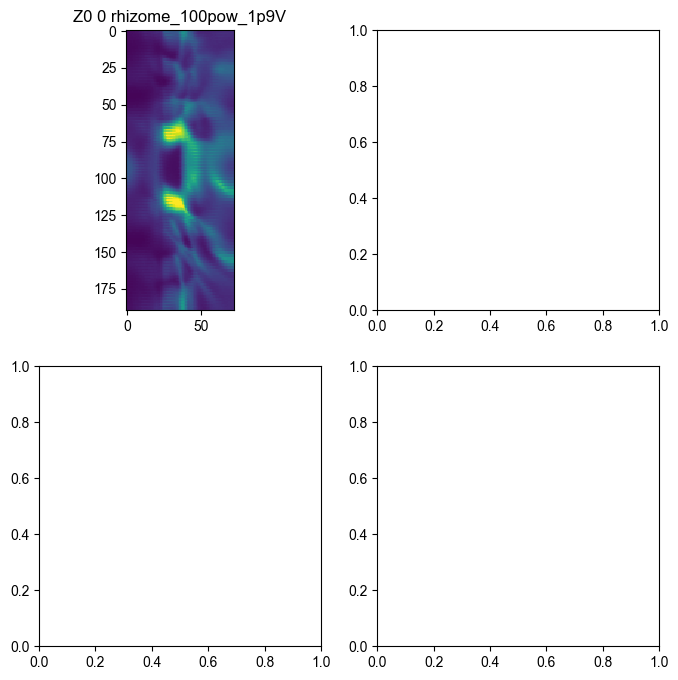

In [317]:
ncol = 2
nrow = 2
scalar = 4
fig,ax = plt.subplots(nrow,ncol,figsize = (ncol*scalar,nrow*scalar))
row = 0
col = 0
for z in range(len(zData)):
    ax[row,col].set_title("Z"+str(z)+" "+str(zData[z]['zPos'])+" "+zData[z]['prefix'])
    ax[row,col].imshow(zData[z]['mergeDataProjs']['mean'],interpolation='none',vmin=-0.5,vmax = np.nanmax(zData[z]['mergeDataProjs']['mean'])*0.9)
    if col+1<ncol:
        col+=1
    else:
        row+=1
        col = 0

In [318]:
z = 0
print("Exporting: "+saveName+"_"+mergeLabel+".tif",end='...')
imwrite(os.path.join(savePath,saveName+"_"+mergeLabel+".tif"),zData[z]['mergeData'],bigtiff=True)
print("Finished!")

Exporting: rhizome_100pow_1p9V_1fileAvg.tif...Finished!


In [301]:
reduceFactor = 100
reduceFrames = np.array(list(range(nFrames2Merge)))
reduceFrames = reduceFrames.reshape(-1,reduceFactor)
nReduceFrames = reduceFrames.shape[0]
for z in range(len(zData)):
    print("Reducing Z"+str(z)+" "+str(zData[z]['zPos'])+" "+zData[z]['prefix'],end='')
    i = zData[z]['loadIndices'][0] 
    zData[z]['mergeData_reduced'] = np.zeros((nReduceFrames,zData[z]['fileInfo'][i]['height'],zData[z]['fileInfo'][i]['width']),dtype='float32')
    for t,frs in enumerate(reduceFrames):
        zData[z]['mergeData_reduced'][t,:,:] = np.nanmean(zData[z]['mergeData'][frs,:,:],axis = 0)
    print("Finished!")

Reducing Z0 0 rhizome_100pow_1p9VFinished!


In [302]:
z = 0
print("Exporting: "+saveName+"_"+mergeLabel+"_"+str(reduceFactor)+'fr.tif',end='...')
reduceStack = np.zeros((nReduceFrames,zData[z]['mergeDataProjs']['mean'].shape[0],zData[z]['mergeDataProjs']['mean'].shape[1]),dtype='float32')
for t,frs in enumerate(reduceFrames):
    reduceStack[t,:,:] = copy.deepcopy(zData[z]['mergeData_reduced'][t,:,:])
imwrite(os.path.join(savePath,saveName+"_"+mergeLabel+"_"+str(reduceFactor)+'fr.tif'),reduceStack,bigtiff=True)
print("Finished!")

Exporting: rhizome_100pow_1p9V_20fileAvg_100fr.tif...Finished!


100
Exporting: rhizome_100pow_1p9V_1fileAvg_1400-1500frs.tif...Finished!


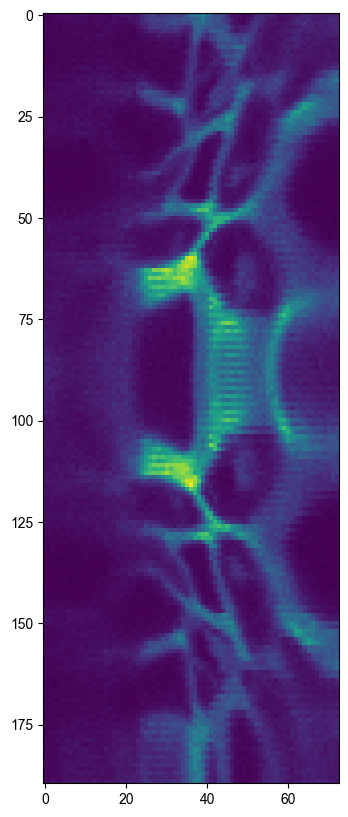

In [322]:
fr_range = [1100,1200]
fr_range = [1100,1150]
fr_range = [1400,1500]
frs = list(range(fr_range[0],fr_range[1]))
print(len(frs))
data=copy.deepcopy(zData[z]['mergeData'][frs,:,:])
data_meanProj = np.nanmean(data,axis=0)
plt.figure(figsize = (10,10))
plt.imshow(data_meanProj)
print("Exporting: "+saveName+"_"+mergeLabel+"_"+str(fr_range[0])+"-"+str(fr_range[1])+'frs.tif',end='...')
imwrite(os.path.join(savePath,saveName+"_"+mergeLabel+"_"+str(fr_range[0])+"-"+str(fr_range[1])+'frs.tif'),data,bigtiff=True)
print("Finished!")

# <font size="5">Bidir EOD Correction

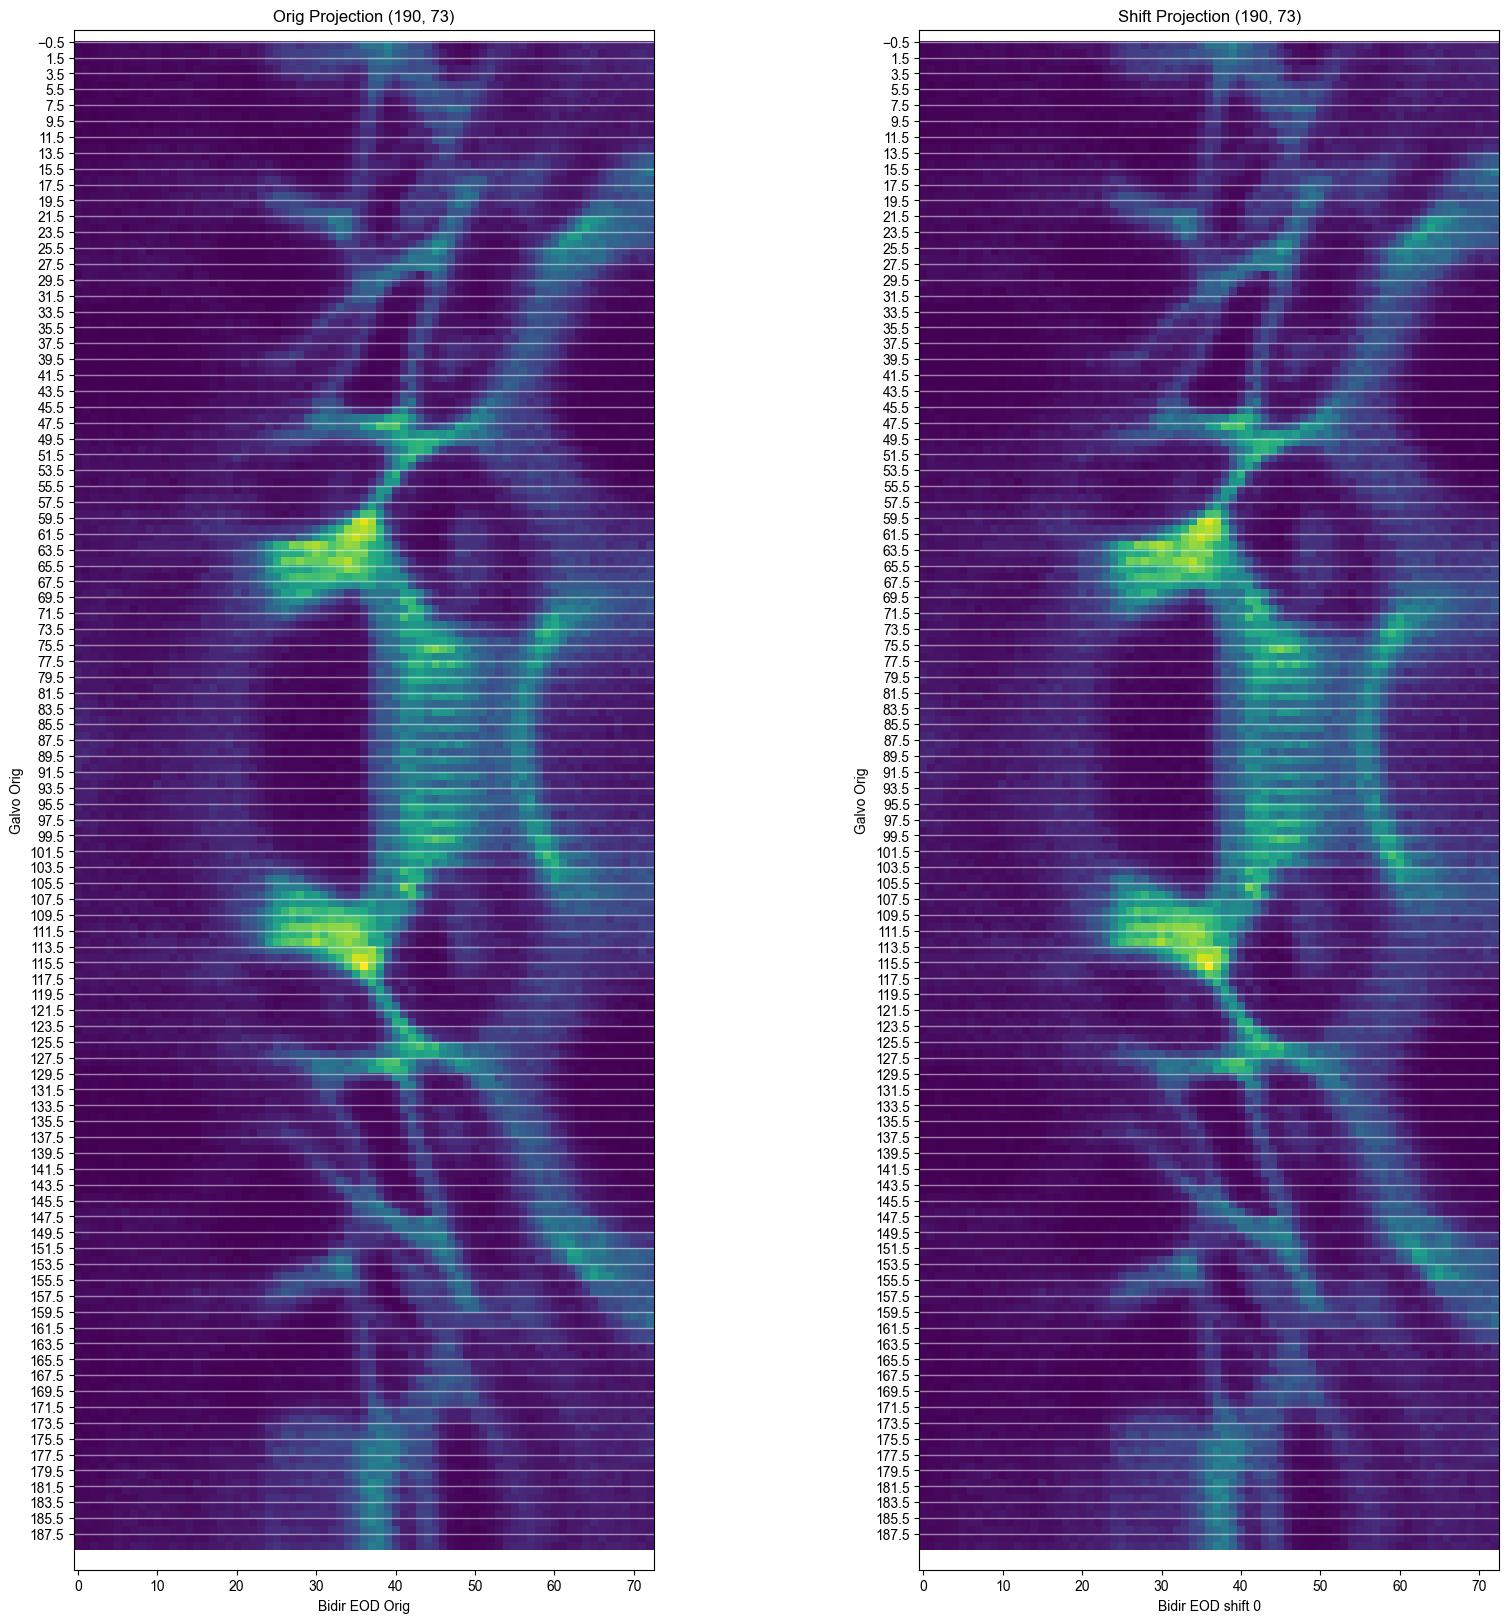

In [323]:
EOD_axis_px_shift = 0 #Operates on ODD indices
data_EOD_Shifted = np.ones((data.shape[0],data.shape[1],data.shape[2]+np.absolute(EOD_axis_px_shift)),dtype='float32')*np.nan
for y in range(data.shape[1]):
    if EOD_axis_px_shift > 0:
        if np.mod(y,2) == 0:
            data_EOD_Shifted[:,y,0:data.shape[2]] = data[:,y,0:data.shape[2]]
            for x in range(data.shape[2],data.shape[2]+np.absolute(EOD_axis_px_shift)):
                data_EOD_Shifted[:,y,x] = data[:,y,data.shape[2]-1]
        else:
            data_EOD_Shifted[:,y,np.absolute(EOD_axis_px_shift):data.shape[2]+np.absolute(EOD_axis_px_shift)] = data[:,y,0:data.shape[2]]
            for x in range(0,np.absolute(EOD_axis_px_shift)):
                data_EOD_Shifted[:,y,x] = data[:,y,0]
    elif EOD_axis_px_shift < 0:
        if np.mod(y,2) == 0:
            data_EOD_Shifted[:,y,np.absolute(EOD_axis_px_shift):data.shape[2]+np.absolute(EOD_axis_px_shift)] = data[:,y,0:data.shape[2]]
        else:
            data_EOD_Shifted[:,y,0:data.shape[2]] = data[:,y,0:data.shape[2]]
    else:
        data_EOD_Shifted[:,y,0:data.shape[2]] = data[:,y,0:data.shape[2]]
data_EOD_Shifted_meanProj = np.nanmean(data_EOD_Shifted,axis=0)
fig,ax = plt.subplots(1,2,figsize = (20,20))
ax[0].imshow(data_meanProj,interpolation='none')
ax[0].set_ylim([data.shape[1]+2,-2])
ax[0].set_ylabel("Galvo Orig")
ax[0].set_xlabel("Bidir EOD Orig")
ax[0].set_title("Orig Projection "+str(data_meanProj.shape))
ax[0].set_yticks(np.arange(0, data_meanProj.shape[0], 2)-0.5)
ax[0].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5,axis = 'y')
ax[1].imshow(data_EOD_Shifted_meanProj,interpolation='none')
ax[1].set_ylim([data.shape[1]+2,-2])
ax[1].set_ylabel("Galvo Orig")
ax[1].set_xlabel("Bidir EOD shift "+str(EOD_axis_px_shift))
ax[1].set_title("Shift Projection "+str(data_EOD_Shifted_meanProj.shape))
ax[1].set_yticks(np.arange(0, data_EOD_Shifted_meanProj.shape[0], 2)-0.5)
ax[1].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5,axis = 'y')


# <font size="5">Bidir EOD Padding

(200, 80)


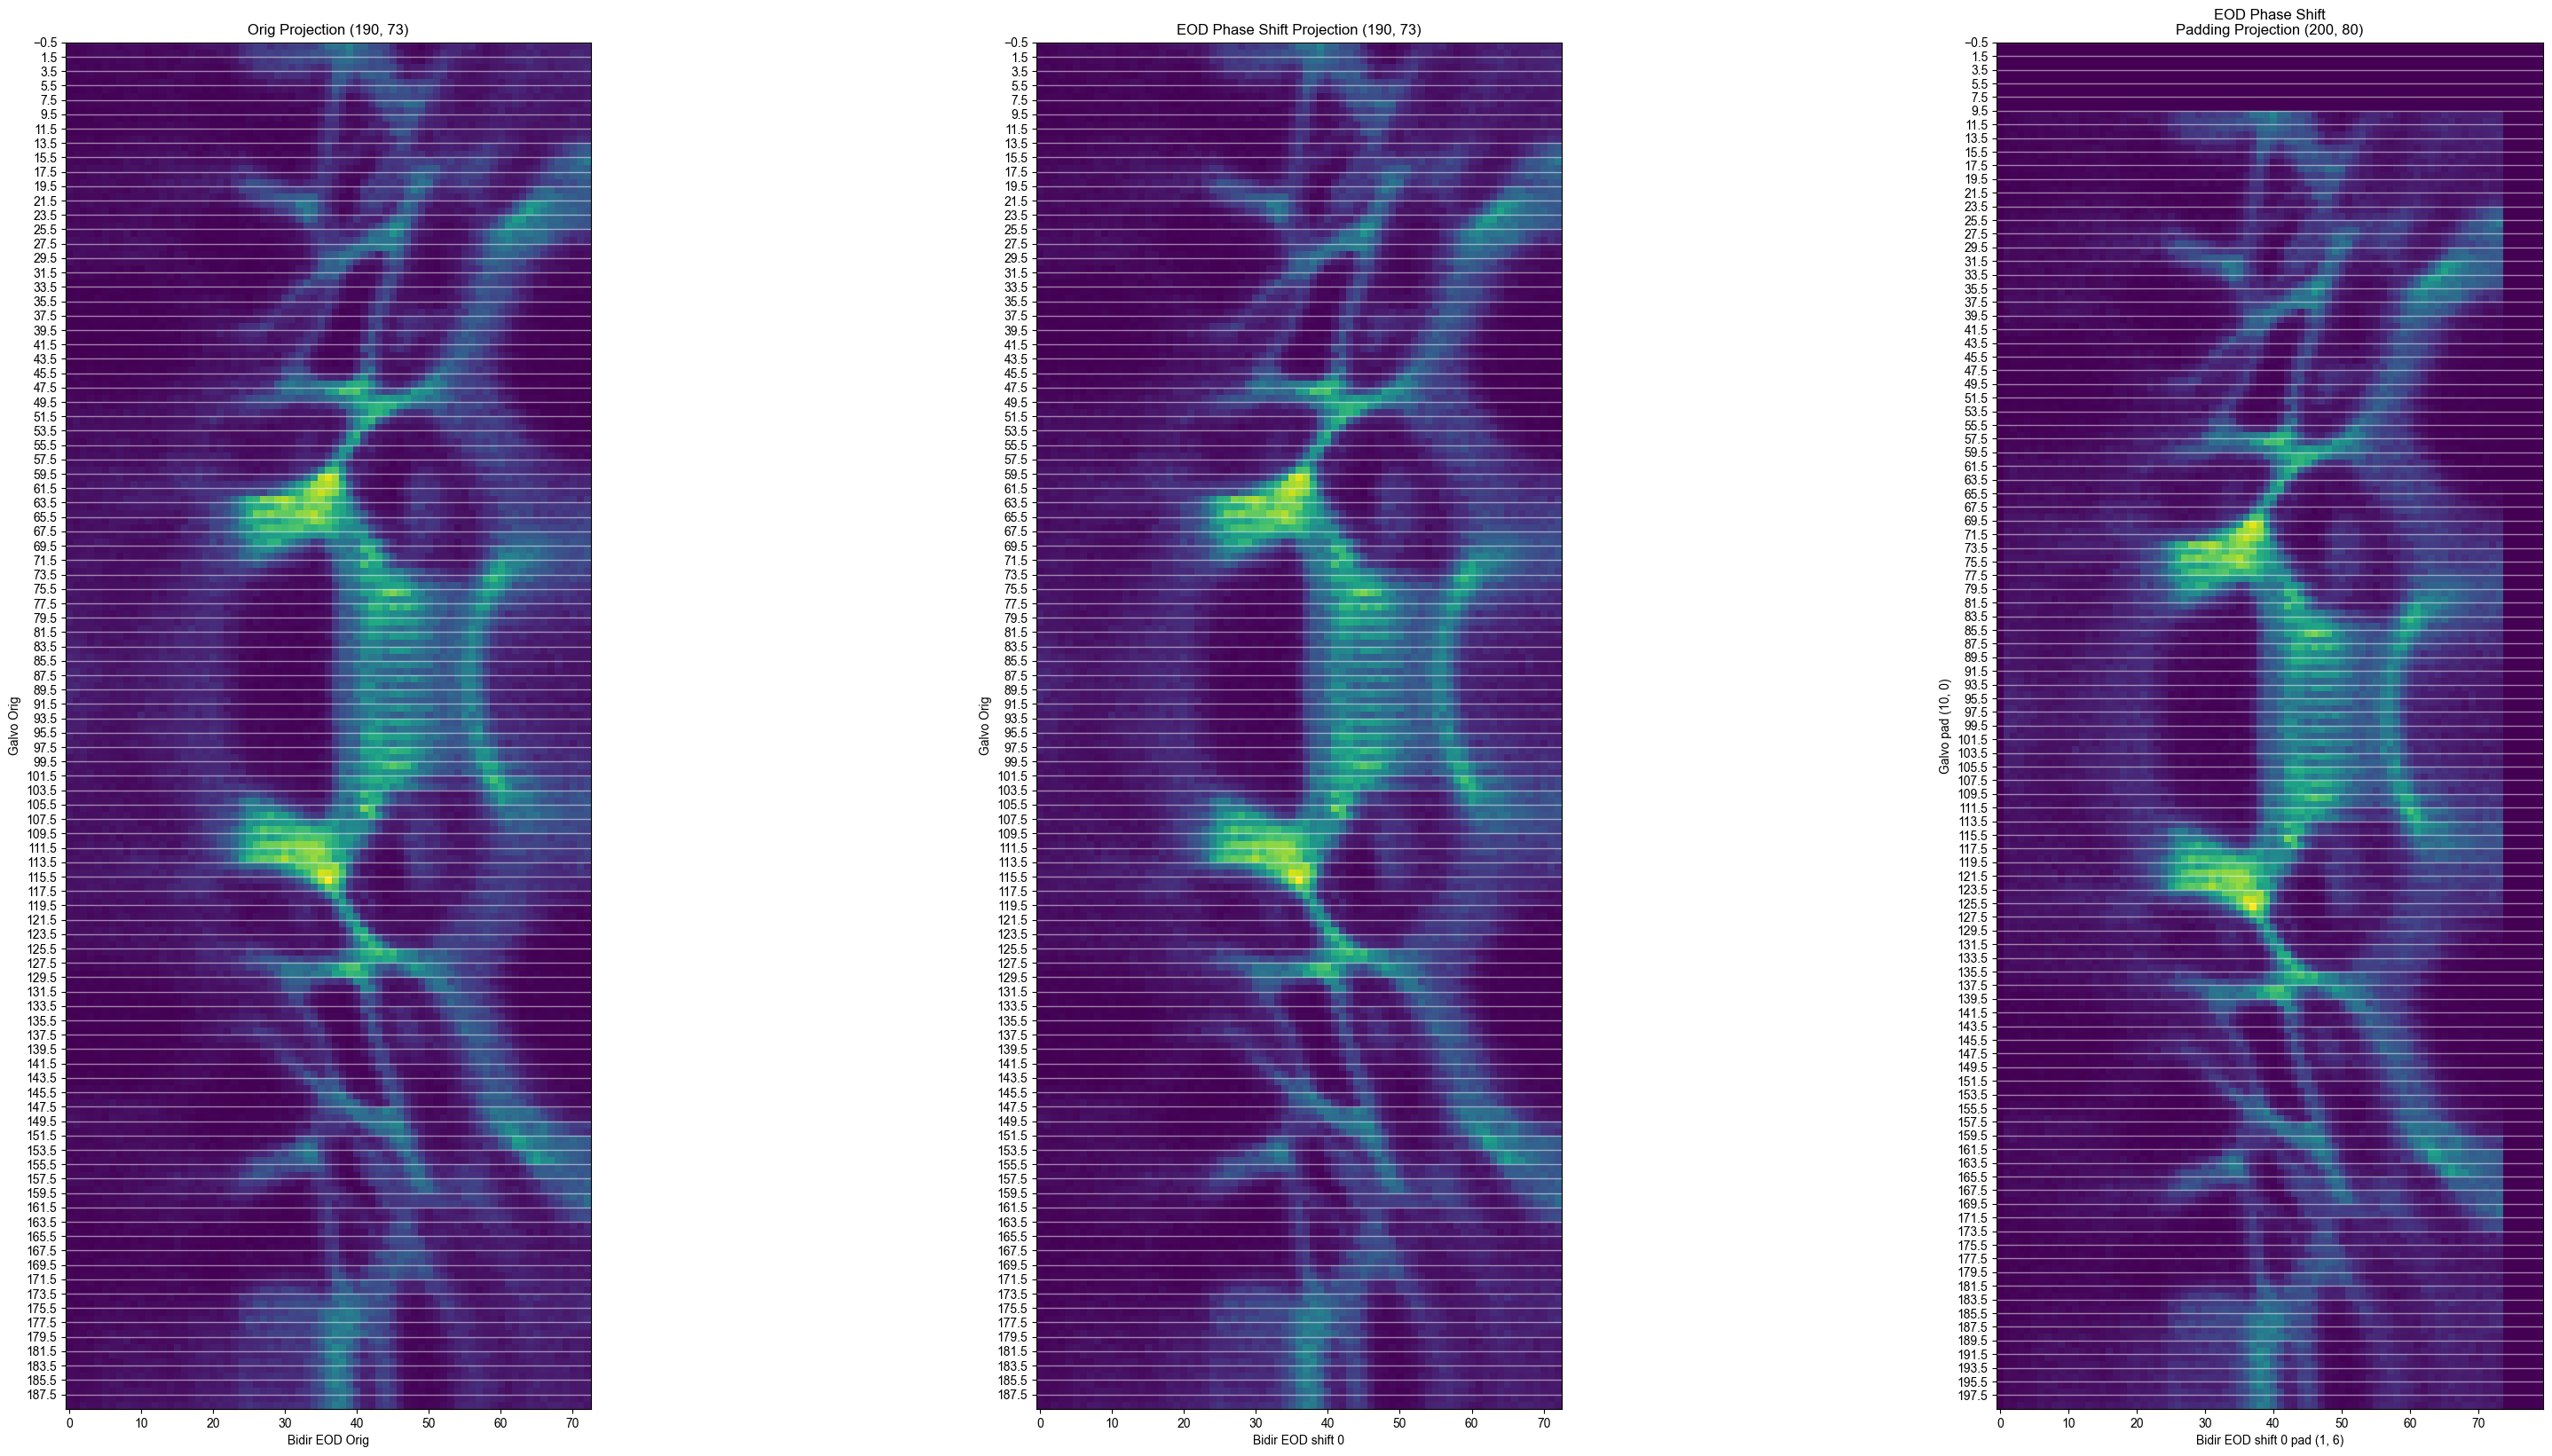

In [324]:
EOD_padding = (1,6)
galvo_padding = (10,0)
padMethod = 'edge'
padMethod = 'constant'
data_EOD_Shifted_pad = np.pad(data_EOD_Shifted, ((0,0), (0, 0), EOD_padding), padMethod)
data_EOD_Shifted_pad = np.pad(data_EOD_Shifted_pad, ((0,0), galvo_padding, (0, 0)), padMethod)
data_EOD_Shifted_pad_meanProj = np.nanmean(data_EOD_Shifted_pad,axis=0)
print(data_EOD_Shifted_pad_meanProj.shape)
fig,ax = plt.subplots(1,3,figsize = (40,20))
ax[0].imshow(data_meanProj,interpolation='none')
ax[0].set_ylabel("Galvo Orig")
ax[0].set_xlabel("Bidir EOD Orig")
ax[0].set_title("Orig Projection "+str(data_meanProj.shape))
ax[0].set_yticks(np.arange(0, data_meanProj.shape[0], 2)-0.5)
ax[0].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5,axis = 'y')
ax[1].imshow(data_EOD_Shifted_meanProj,interpolation='none')
ax[1].set_ylabel("Galvo Orig")
ax[1].set_xlabel("Bidir EOD shift "+str(EOD_axis_px_shift))
ax[1].set_title("EOD Phase Shift Projection "+str(data_EOD_Shifted_meanProj.shape))
ax[1].set_yticks(np.arange(0, data_EOD_Shifted_meanProj.shape[0], 2)-0.5)
ax[1].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5,axis = 'y')
ax[2].imshow(data_EOD_Shifted_pad_meanProj,interpolation='none')
ax[2].set_ylabel("Galvo pad "+str(galvo_padding))
ax[2].set_xlabel("Bidir EOD shift "+str(EOD_axis_px_shift)+" pad "+str(EOD_padding))
ax[2].set_title("EOD Phase Shift\nPadding Projection "+str(data_EOD_Shifted_pad_meanProj.shape))
ax[2].set_yticks(np.arange(0, data_EOD_Shifted_pad_meanProj.shape[0], 2)-0.5)
ax[2].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5,axis = 'y')


(-1.0, 80.5)

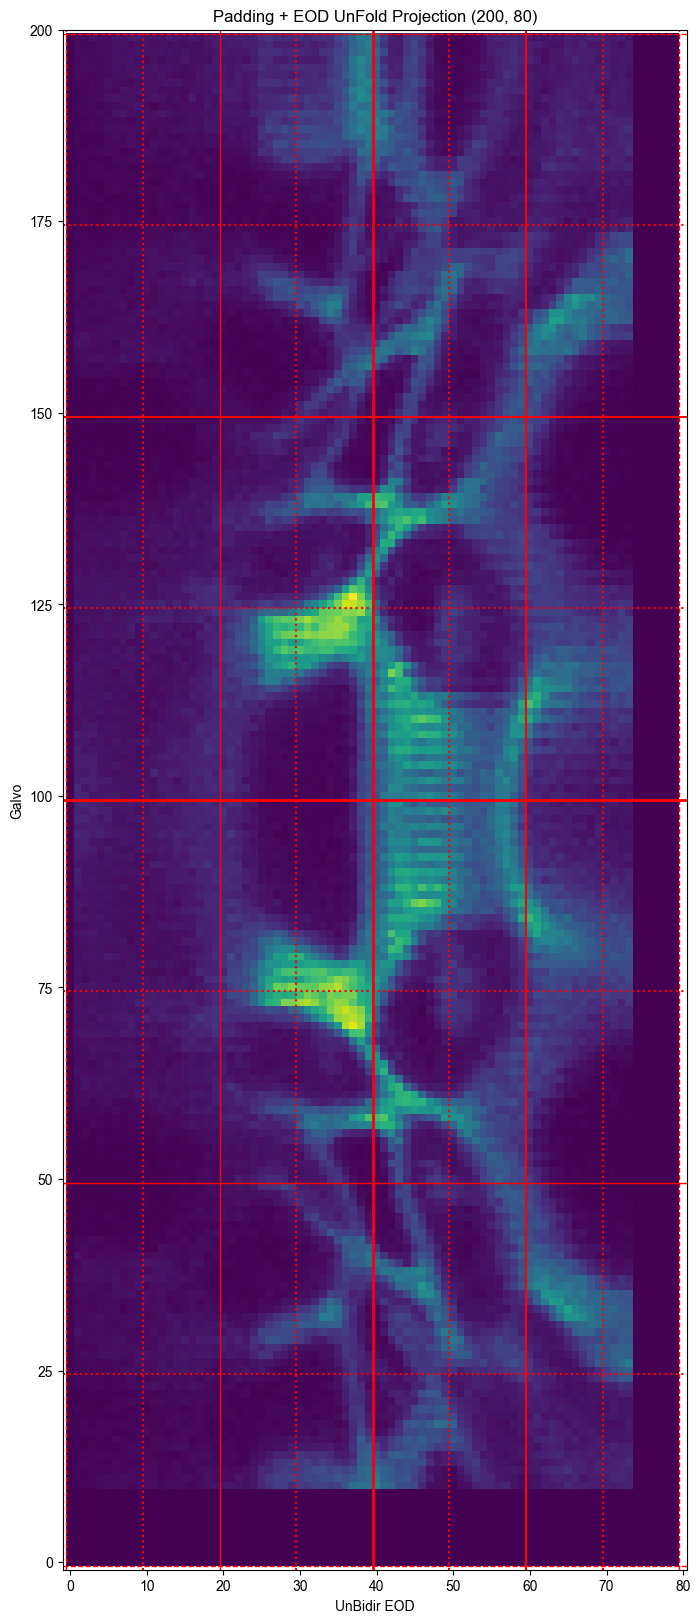

In [325]:
plt.figure(figsize = (20,20))
plt.imshow(data_EOD_Shifted_pad_meanProj,interpolation='none',)
plt.axvline(np.floor(data_EOD_Shifted_pad_meanProj.shape[1]*(0/8))-0.5,lw = 1,linestyle='--',color =(1,0,0))
plt.axvline(np.floor(data_EOD_Shifted_pad_meanProj.shape[1]*(1/8))-0.5,linestyle=':',color =(1,0,0))
plt.axvline(np.floor(data_EOD_Shifted_pad_meanProj.shape[1]*(2/8))-0.5,lw = 1, color =(1,0,0))
plt.axvline(np.floor(data_EOD_Shifted_pad_meanProj.shape[1]*(3/8))-0.5,linestyle=':',color =(1,0,0))
plt.axvline(np.round(data_EOD_Shifted_pad_meanProj.shape[1]*(4/8))-0.5,lw = 2, color =(1,0,0))
plt.axvline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[1]*(5/8))-0.5,linestyle=':',color =(1,0,0))
plt.axvline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[1]*(6/8))-0.5,color =(1,0,0))
plt.axvline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[1]*(7/8))-0.5,linestyle=':',color =(1,0,0))
plt.axvline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[1]*(8/8))-0.5,lw = 1,linestyle='--',color =(1,0,0))
plt.axhline(np.floor(data_EOD_Shifted_pad_meanProj.shape[0]*(0/8))-0.5,lw = 1,linestyle='--',color =(1,0,0))
plt.axhline(np.floor(data_EOD_Shifted_pad_meanProj.shape[0]*(1/8))-0.5,linestyle=':',color =(1,0,0))
plt.axhline(np.floor(data_EOD_Shifted_pad_meanProj.shape[0]*(2/8))-0.5,lw = 1, color =(1,0,0))
plt.axhline(np.floor(data_EOD_Shifted_pad_meanProj.shape[0]*(3/8))-0.5,linestyle=':',color =(1,0,0))
plt.axhline(np.round(data_EOD_Shifted_pad_meanProj.shape[0]*(4/8))-0.5,lw = 2, color =(1,0,0))
plt.axhline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[0]*(5/8))-0.5,linestyle=':',color =(1,0,0))
plt.axhline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[0]*(6/8))-0.5,color =(1,0,0))
plt.axhline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[0]*(7/8))-0.5,linestyle=':',color =(1,0,0))
plt.axhline(np.ceil(data_EOD_Shifted_pad_meanProj.shape[0]*(8/8))-0.5,lw = 1,linestyle='--',color =(1,0,0))
plt.ylabel("Galvo")
plt.xlabel("UnBidir EOD")
plt.title("Padding + EOD UnFold Projection "+str(data_EOD_Shifted_pad_meanProj.shape))
plt.ylim([-1,data_EOD_Shifted_pad_meanProj.shape[0]])
plt.xlim([-1,data_EOD_Shifted_pad_meanProj.shape[1]+0.5])

# <font size="5">Splatting

In [127]:
import numpy as np

def forward_warp_sum_unified(
    src,
    Xf,
    Yf,
    out_shape=None,
    method='bilinear',
    k=1,
    return_counts=True,
    dtype=np.float64,
):
    """
    Forward-warp (push/splat) with accumulation, optionally with supersampling.

    Parameters
    ----------
    src : (H, W) or (H, W, C) array
        Source image/values. Use float for precise accumulation.
    Xf, Yf : (H, W) float arrays
        FORWARD maps: for each source pixel center (y, x) give destination coords (x_d, y_d).
        Example: Xf[y, x], Yf[y, x] are the destination coordinates for src[y, x].
        Coordinates are in pixel units of the *final* output grid (before supersampling).
    out_shape : (Hd, Wd) or None
        Final output size. If None, a minimal bounding box is inferred from Xf, Yf.
        When k>1, this is the final (downsampled) size; accumulation happens on (Hd*k, Wd*k).
    method : {'nearest', 'bilinear'}
        Splatting kernel:
            - 'nearest'   : each sample contributes to the nearest integer pixel.
            - 'bilinear'  : each sample contributes to 4 neighbors with bilinear weights.
    k : int >= 1
        Supersampling factor. k=1 → no supersampling. k>1 → accumulate on a k× finer grid
        and block-sum down to the requested out_shape.
    return_counts : bool
        If True, also return an array of accumulated weights (useful for density normalization).
    dtype : numpy dtype
        Accumulator dtype (np.float64 by default for numerical stability).

    Returns
    -------
    out : (Hd, Wd) or (Hd, Wd, C) array
        Accumulated sum (mass/flux) image.
    counts : (Hd, Wd) array
        Sum of splat weights per pixel (only if return_counts=True).
    """
    src = np.asarray(src)
    Hs, Ws = src.shape[:2]
    C = 1 if src.ndim == 2 else src.shape[2]

    Xf = np.asarray(Xf)
    Yf = np.asarray(Yf)
    assert Xf.shape == (Hs, Ws) and Yf.shape == (Hs, Ws), "Xf/Yf must match src HxW."

    # Infer final output shape if not provided (based on *final* grid coordinates).
    if out_shape is None:
        x_min = np.nanmin(Xf); y_min = np.nanmin(Yf)
        x_max = np.nanmax(Xf); y_max = np.nanmax(Yf)
        Wd = int(np.ceil(x_max + 1))
        Hd = int(np.ceil(y_max + 1))
    else:
        Hd, Wd = out_shape

    # High-resolution (supersampled) grid
    k = int(k)
    if k < 1:
        raise ValueError("k must be >= 1")
    Hd_hr, Wd_hr = Hd * k, Wd * k

    # Scale destination coordinates to high-res canvas if supersampling
    if k == 1:
        xd = Xf.reshape(-1)
        yd = Yf.reshape(-1)
    else:
        xd = (Xf * k).reshape(-1)
        yd = (Yf * k).reshape(-1)
    
    # print(Hd_hr, Wd_hr)
    # Prepare accumulators on the high-res grid
    out_hr = np.zeros((Hd_hr, Wd_hr, C), dtype=dtype)
    counts_hr = np.zeros((Hd_hr, Wd_hr), dtype=dtype)

    # Flatten values
    if C == 1:
        vals = src.reshape(-1).astype(dtype)
    else:
        vals = src.reshape(-1, C).astype(dtype)

    # -------- splatting kernels --------
    if method == 'nearest':
        xi = np.rint(xd).astype(np.int32)
        yi = np.rint(yd).astype(np.int32)

        m = (xi >= 0) & (xi < Wd_hr) & (yi >= 0) & (yi < Hd_hr) & np.isfinite(xd) & np.isfinite(yd)
        xi = xi[m]; yi = yi[m]
        if C == 1:
            np.add.at(out_hr[..., 0], (yi, xi), vals[m])
        else:
            for c in range(C):
                np.add.at(out_hr[..., c], (yi, xi), vals[m, c])
        np.add.at(counts_hr, (yi, xi), 1.0)

    elif method == 'bilinear':
        x0 = np.floor(xd).astype(np.int32)
        y0 = np.floor(yd).astype(np.int32)
        dx = xd - x0
        dy = yd - y0

        # 4 neighbors
        neigh = [
            (x0,     y0,     (1 - dx) * (1 - dy)),  # (x0, y0)
            (x0 + 1, y0,     dx       * (1 - dy)),  # (x0+1, y0)
            (x0,     y0 + 1, (1 - dx) * dy),        # (x0, y0+1)
            (x0 + 1, y0 + 1, dx       * dy)         # (x0+1, y0+1)
        ]

        for xn, yn, w in neigh:
            m = (xn >= 0) & (xn < Wd_hr) & (yn >= 0) & (yn < Hd_hr) & np.isfinite(w)
            xn = xn[m]; yn = yn[m]; wv = w[m]
            if C == 1:
                np.add.at(out_hr[..., 0], (yn, xn), vals[m] * wv)
            else:
                for c in range(C):
                    np.add.at(out_hr[..., c], (yn, xn), vals[m, c] * wv)
            np.add.at(counts_hr, (yn, xn), wv)
    else:
        raise ValueError("method must be 'nearest' or 'bilinear'.")

    # -------- downsample by block-sum if supersampled --------
    if k == 1:
        out = out_hr
        counts = counts_hr
    else:
        if C == 1:
            out = out_hr.reshape(Hd, k, Wd, k).sum(axis=(1, 3))
        else:
            out = out_hr.reshape(Hd, k, Wd, k, C).sum(axis=(1, 3))
        counts = counts_hr.reshape(Hd, k, Wd, k).sum(axis=(1, 3))
    out = np.squeeze(out)
    counts = np.squeeze(counts)
    # # Remove last channel dim for grayscale to match input style
    # if C == 1:
    #     out = out[..., 0]

    return (out, counts) if return_counts else out

In [128]:
EOD_bidir_turn_px = 10

EOD_distortion_factor = 0.1 * np.array([-1, 1])
EOD_correction_freq = 0.5
EOD_phase_shift = True
EOD_correction_phase_shift_px = EOD_bidir_turn_px
EOD_correction_shift_px = 0
EOD_distortion = 'sin' #cos
EOD_interpolation = 'bilinear'
# EOD_interpolation = 'nearest'
EOD_supersample = 1
EOD_apply_weights = True
# EOD_shiftX = 10

galvo_bidir_turn_px = 100
# galvo_distortion_factor = 0.2 * np.array([-1, 1, -1, 1])
# galvo_correction_freq = 0.8
# galvo_phase_shift = True
# galvo_correction_phase_shift_px = -25
galvo_distortion_factor = 0.12 * np.array([-1, 1, -1, 1])
galvo_correction_freq = 1
galvo_phase_shift = True
galvo_correction_phase_shift_px = 0
galvo_correction_shift_px = 0
galvo_distortion = 'sin' #cos
galvo_interpolation = 'bilinear'
# galvo_interpolation = 'nearest'
galvo_supersample = 1
galvo_apply_weights = True
# galvo_shiftY = 20

finalSize = [200,80]
# finalSize = [00,80]
mergeThresh = 0

In [129]:
##############################################################
#Initial Set up EOD Corrections
EOD_xdata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[1])
EOD_rel_xdata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[1])-EOD_bidir_turn_px
h, w = data_EOD_Shifted_pad_meanProj.shape[:2]
EOD_orig_map_x, EOD_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if EOD_distortion == 'sin' or EOD_distortion == 'cos':
    x1_norm = ((EOD_orig_map_x) / (w)) * 2 * np.pi * EOD_correction_freq
    if EOD_phase_shift:
        EOD_correction_phase_shift = (EOD_correction_phase_shift_px/w)* 2 * np.pi * EOD_correction_freq
        print(f'EOD_correction_phase_shift = {EOD_correction_phase_shift}')
    else:
        EOD_correction_phase_shift = 0
else:
    x1_norm = ((EOD_orig_map_x) / (w))
    if EOD_phase_shift:
        EOD_correction_phase_shift = (EOD_correction_phase_shift_px/w)
        print(f'EOD_correction_phase_shift = {EOD_correction_phase_shift}')
    else:
        EOD_correction_phase_shift = 0
##############################################################
#Generate EOD Distortion Field
if EOD_distortion == 'sin':
    EOD_distortion_field = np.sin(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.sin(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.cos(x1_norm[0,:]-EOD_correction_phase_shift) * -1
elif EOD_distortion == 'cos':
    EOD_distortion_field = np.cos(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.cos(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.sin(x1_norm[0,:]-EOD_correction_phase_shift) * -1
elif EOD_distortion == 'lin':
    EOD_distortion_field = (x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = (x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = (x1_norm[0,:]-EOD_correction_phase_shift) * -1
EOD_distortion_field = np.absolute(np.absolute(EOD_distortion_field)-w)
EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] = EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] * EOD_distortion_factor[0]
EOD_distortion_field[:,np.nanargmax(EOD_speed):w] = EOD_distortion_field[:,np.nanargmax(EOD_speed):w] * EOD_distortion_factor[1]
EOD_correction_map = EOD_orig_map_x + EOD_distortion_field
EOD_correction_map_x = EOD_correction_map.astype(np.float32)
EOD_orig_map_y = EOD_orig_map_y.astype(np.float32)
EOD_distortion_correction = EOD_orig_map_x-EOD_correction_map_x
EOD_correction_map_x = EOD_orig_map_x + EOD_distortion_correction
# EOD_correction_map_x[0:EOD_bidir_turn_px,:] = 0
##############################################################
# Test EOD Correction
tempImg = copy.deepcopy(data_EOD_Shifted_pad_meanProj)
tempImg[0:EOD_bidir_turn_px,:] = 0
test_EOD_correction = forward_warp_sum_unified(
    tempImg,
    EOD_correction_map_x,
    EOD_orig_map_y,
    out_shape=finalSize,
    method=EOD_interpolation,
    k=EOD_supersample,
    return_counts=True,
    dtype=np.float32)
test_EOD_corrected_data = copy.deepcopy(test_EOD_correction[0])
test_EOD_corrected_weights = copy.deepcopy(test_EOD_correction[1])
if EOD_apply_weights:
    test_EOD_corrected_adjusted_data = np.divide(test_EOD_corrected_data,  test_EOD_corrected_weights)
    test_EOD_corrected_adjusted_data[np.isnan(test_EOD_corrected_adjusted_data)] = 0
else:
    test_EOD_corrected_adjusted_data = test_EOD_corrected_data
##############################################################
#Initial Set up Galvo Corrections
galvo_ydata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[0])
galvo_rel_ydata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[0])-galvo_bidir_turn_px
h, w = data_EOD_Shifted_pad_meanProj.shape[:2]
galvo_orig_map_x, galvo_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if galvo_distortion == 'sin' or galvo_distortion == 'cos':
    if galvo_phase_shift:
        galvo_correction_phase_shift = (galvo_correction_phase_shift_px/h)* 2 * np.pi * galvo_correction_freq
        print(f'galvo_correction_phase_shift = {galvo_correction_phase_shift}')
    else:
        galvo_correction_phase_shift = 0
    y1_norm = ((galvo_orig_map_y) / (h)) * 2 * np.pi * galvo_correction_freq
else:
    if galvo_phase_shift:
        galvo_correction_phase_shift = (galvo_correction_phase_shift_px/h)
        print(f'galvo_correction_phase_shift = {galvo_correction_phase_shift}')
    else:
        galvo_correction_phase_shift = 0
    y1_norm = ((galvo_orig_map_y) / (h))
##############################################################
#Generate GALVO Distortion Field
if galvo_distortion == 'sin':
    galvo_distortion_field = np.sin(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.sin(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.cos(y1_norm[:,0]-galvo_correction_phase_shift) * -1
elif galvo_distortion == 'cos':
    galvo_distortion_field = np.cos(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.cos(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.sin(y1_norm[:,0]-galvo_correction_phase_shift) * -1
elif galvo_distortion == 'lin':
    galvo_distortion_field = (y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = (y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = (y1_norm[:,0]-galvo_correction_phase_shift) * -1

galvo_distortion_field = np.absolute(np.absolute(galvo_distortion_field)-h)
galvo_distortion_field[0:np.nanargmax(galvo_speed),:] = galvo_distortion_field[0:np.nanargmax(galvo_speed),:] * galvo_distortion_factor[0]
galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] = galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] * galvo_distortion_factor[1]
galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] = galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] * galvo_distortion_factor[2]
galvo_distortion_field[np.nanargmin(galvo_speed):h,:] = galvo_distortion_field[np.nanargmin(galvo_speed):h,:] * galvo_distortion_factor[3]
galvo_correction_map = galvo_orig_map_y + galvo_distortion_field
galvo_correction_map_y = galvo_correction_map.astype(np.float32)
galvo_orig_map_x = galvo_orig_map_x.astype(np.float32)
galvo_distortion_correction = galvo_orig_map_y-galvo_correction_map_y
galvo_correction_map_y = galvo_orig_map_y + galvo_distortion_correction
##############################################################
#Test Galvo Correction
tempImg = copy.deepcopy(data_EOD_Shifted_pad_meanProj)
test_galvo_correction = forward_warp_sum_unified(
    tempImg,
    galvo_orig_map_x,
    galvo_correction_map_y,
    out_shape=finalSize,
    method=galvo_interpolation,
    k=EOD_supersample,
    return_counts=True,
    dtype=np.float32)
test_galvo_corrected_data = copy.deepcopy(test_galvo_correction[0])
test_galvo_corrected_weights = copy.deepcopy(test_galvo_correction[1])
if galvo_apply_weights:
    test_galvo_corrected_adjusted_data = np.divide(test_galvo_corrected_data,  test_galvo_corrected_weights)
    test_galvo_corrected_adjusted_data[np.isnan(test_galvo_corrected_adjusted_data)] = 0
else:
    test_galvo_corrected_adjusted_data = test_galvo_corrected_data

EOD_correction_phase_shift = 0.39269908169872414
galvo_correction_phase_shift = 0.0


/tmp/ipykernel_1526198/1504230813.py:60: RuntimeWarning: invalid value encountered in true_divide
  test_EOD_corrected_adjusted_data = np.divide(test_EOD_corrected_data,  test_EOD_corrected_weights)
/tmp/ipykernel_1526198/1504230813.py:124: RuntimeWarning: invalid value encountered in true_divide
  test_galvo_corrected_adjusted_data = np.divide(test_galvo_corrected_data,  test_galvo_corrected_weights)


(200.5, -0.5)

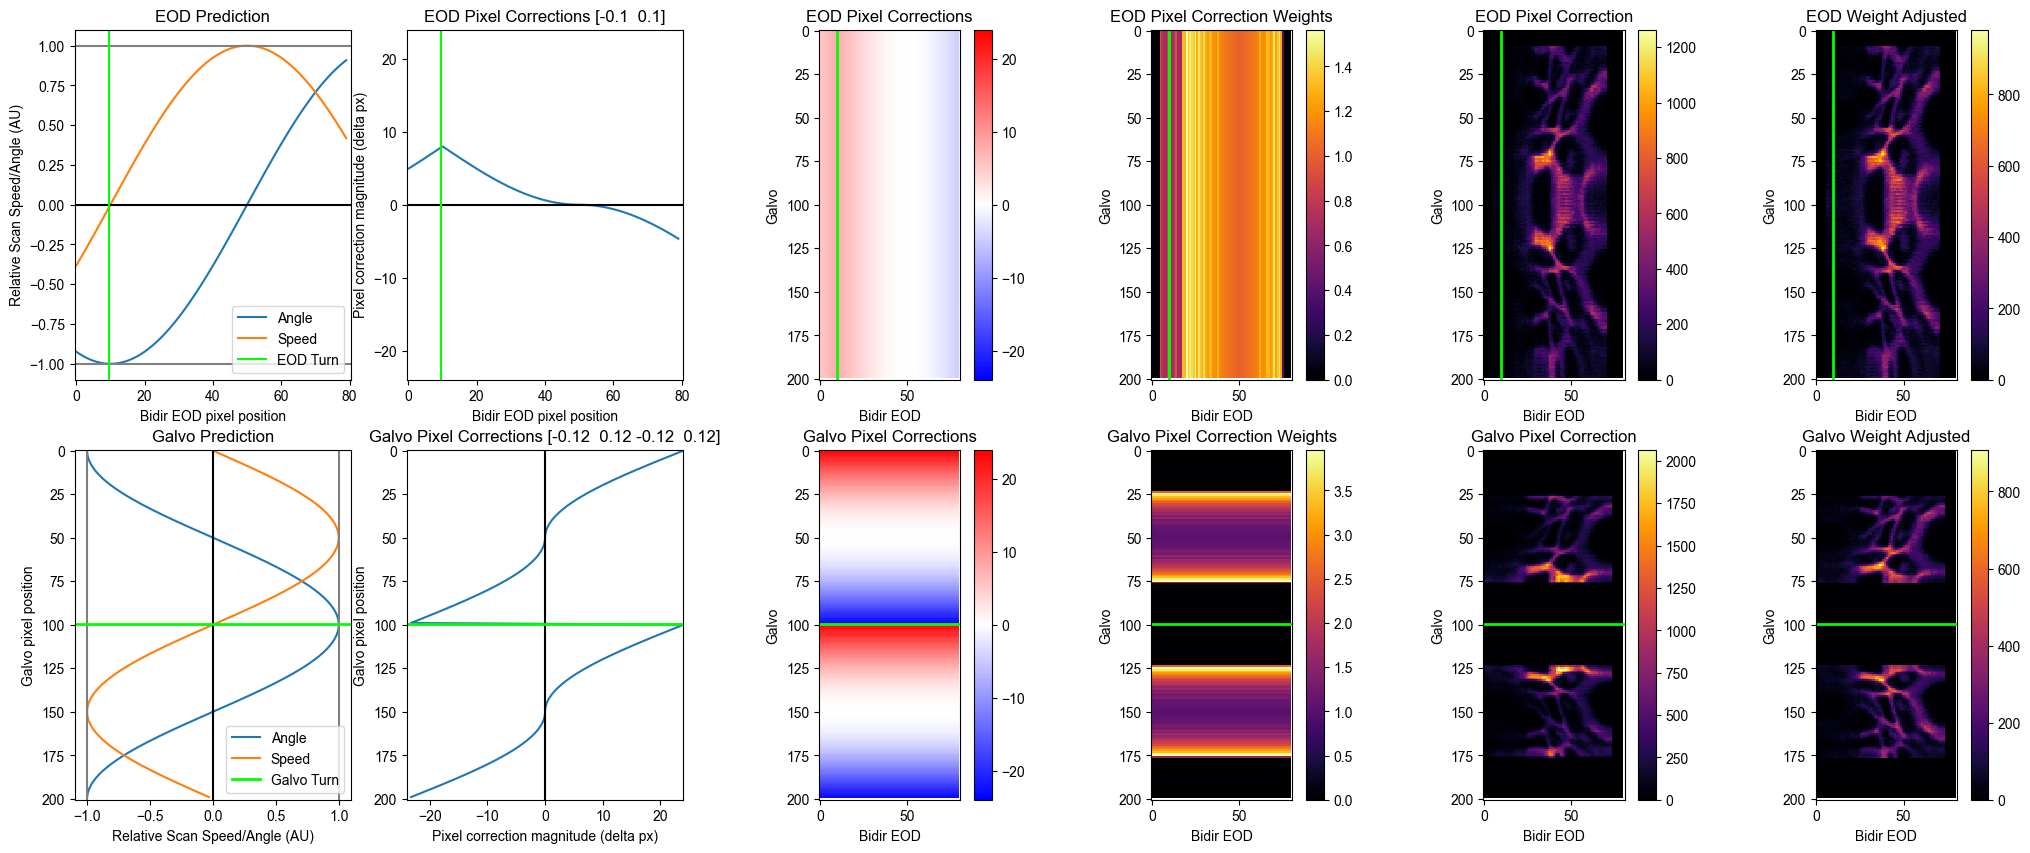

In [130]:
max_distortion_correction = np.max([np.max(np.absolute(EOD_distortion_correction)), np.max(np.absolute(galvo_distortion_correction))])
##############################################################
fig,ax = plt.subplots(2,6,figsize = (25,10))
ax[0,0].plot(EOD_xdata,EOD_angle,label='Angle')
ax[0,0].plot(EOD_xdata,EOD_speed,label='Speed')
ax[0,0].axhline(-1,color = (0.5,0.5,0.5))
ax[0,0].axhline(0,color = (0,0,0))
ax[0,0].axhline(1,color = (0.5,0.5,0.5))
ax[0,0].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),label='EOD Turn')
ax[0,0].legend()
ax[0,0].set_xlim([-0.5,data_EOD_Shifted_pad_meanProj.shape[1]+0.5])
ax[0,0].set_title('EOD Prediction')
ax[0,0].set_xlabel('Bidir EOD pixel position')
ax[0,0].set_ylabel('Relative Scan Speed/Angle (AU)')

ax[0,1].plot(EOD_xdata,EOD_distortion_field[0,:]*-1)
ax[0,1].axhline(0,color = (0,0,0))
ax[0,1].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0))
ax[0,1].set_xlim([-0.5,data_EOD_Shifted_pad_meanProj.shape[1]+0.5])
ax[0,1].set_ylim([-1*max_distortion_correction,max_distortion_correction])
ax[0,1].set_title('EOD Pixel Corrections '+str(EOD_distortion_factor))
ax[0,1].set_xlabel('Bidir EOD pixel position')
ax[0,1].set_ylabel('Pixel correction magnitude (delta px)')

im = ax[0,2].imshow(EOD_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
plt.colorbar(im)
# ax[0,2].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[0,2].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[0,2].set_title('EOD Pixel Corrections')
ax[0,2].set_xlabel('Bidir EOD')
ax[0,2].set_ylabel('Galvo')
ax[0,2].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[0,2].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])

im = ax[0,3].imshow(test_EOD_corrected_weights,interpolation='none',cmap='inferno',\
           vmin=0,vmax=np.max(test_EOD_corrected_weights))
plt.colorbar(im)
# ax[0,2].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[0,3].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[0,3].set_title('EOD Pixel Correction Weights')
ax[0,3].set_xlabel('Bidir EOD')
ax[0,3].set_ylabel('Galvo')
ax[0,3].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[0,3].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])

im = ax[0,4].imshow(test_EOD_corrected_data,interpolation='none',cmap='inferno',\
           vmin=0,vmax=np.max(test_EOD_corrected_data))
plt.colorbar(im)
# ax[0,4].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[0,4].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[0,4].set_title('EOD Pixel Correction')
ax[0,4].set_xlabel('Bidir EOD')
ax[0,4].set_ylabel('Galvo')
ax[0,4].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[0,4].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])

im = ax[0,5].imshow(test_EOD_corrected_adjusted_data,interpolation='none',cmap='inferno')
plt.colorbar(im)
# ax[0,4].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[0,5].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[0,5].set_title('EOD Weight Adjusted')
ax[0,5].set_xlabel('Bidir EOD')
ax[0,5].set_ylabel('Galvo')
ax[0,5].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[0,5].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])



ax[1,0].plot(galvo_angle,galvo_ydata,label='Angle')
ax[1,0].plot(galvo_speed,galvo_ydata,label='Speed')
ax[1,0].axvline(-1,color = (0.5,0.5,0.5))
ax[1,0].axvline(0,color = (0,0,0))
ax[1,0].axvline(1,color = (0.5,0.5,0.5))
ax[1,0].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2,label='Galvo Turn')
ax[1,0].legend()
ax[1,0].set_ylim([data_EOD_Shifted_pad_meanProj.shape[0]+0.5,-0.5])
ax[1,0].set_title('Galvo Prediction')
ax[1,0].set_ylabel('Galvo pixel position')
ax[1,0].set_xlabel('Relative Scan Speed/Angle (AU)')

ax[1,1].plot(galvo_distortion_field[:,0]*-1,galvo_ydata)
ax[1,1].axvline(0,color = (0,0,0))
ax[1,1].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,1].set_ylim([data_EOD_Shifted_pad_meanProj.shape[0]+0.5,-0.5])
ax[1,1].set_xlim([-1*max_distortion_correction,max_distortion_correction])
ax[1,1].set_title('Galvo Pixel Corrections '+str(galvo_distortion_factor))
ax[1,1].set_ylabel('Galvo pixel position')
ax[1,1].set_xlabel('Pixel correction magnitude (delta px)')

im = ax[1,2].imshow(galvo_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
ax[1,2].invert_yaxis()
plt.colorbar(im)
ax[1,2].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,2].set_title('Galvo Pixel Corrections')
ax[1,2].set_xlabel('Bidir EOD')
ax[1,2].set_ylabel('Galvo')
ax[1,2].set_xlim([-0.5,galvo_distortion_correction.shape[1]+0.5])
ax[1,2].set_ylim([galvo_distortion_correction.shape[0]+0.5,-0.5])

im = ax[1,3].imshow(test_galvo_corrected_weights,interpolation='none',cmap='inferno',\
           vmin=0,vmax=np.max(test_galvo_corrected_weights))
plt.colorbar(im)
# ax[1,2].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[1,3].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,3].set_title('Galvo Pixel Correction Weights')
ax[1,3].set_xlabel('Bidir EOD')
ax[1,3].set_ylabel('Galvo')
ax[1,3].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[1,3].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])

im = ax[1,4].imshow(test_galvo_corrected_data,interpolation='none',cmap='inferno',\
           vmin=0,vmax=np.max(test_galvo_corrected_data))
plt.colorbar(im)
# ax[1,4].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[1,4].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,4].set_title('Galvo Pixel Correction')
ax[1,4].set_xlabel('Bidir EOD')
ax[1,4].set_ylabel('Galvo')
ax[1,4].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[1,4].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])

im = ax[1,5].imshow(test_galvo_corrected_adjusted_data,interpolation='none',cmap='inferno')
plt.colorbar(im)
# ax[1,4].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[1,5].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,5].set_title('Galvo Weight Adjusted')
ax[1,5].set_xlabel('Bidir EOD')
ax[1,5].set_ylabel('Galvo')
ax[1,5].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[1,5].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])

/tmp/ipykernel_1526198/3052988760.py:21: RuntimeWarning: invalid value encountered in true_divide
  EOD_corrected_data = np.divide(EOD_corrected_data,  EOD_corrected_weights)
/tmp/ipykernel_1526198/3052988760.py:46: RuntimeWarning: invalid value encountered in true_divide
  galvo_corrected_data = np.divide(galvo_corrected_data,  galvo_corrected_weights)
/tmp/ipykernel_1526198/3052988760.py:68: RuntimeWarning: invalid value encountered in true_divide
  galvo_corrected_data = np.divide(galvo_corrected_data,  galvo_corrected_weights)
/tmp/ipykernel_1526198/3052988760.py:93: RuntimeWarning: invalid value encountered in true_divide
  galvo_corrected_data = np.divide(galvo_corrected_data,  galvo_corrected_weights)
/tmp/ipykernel_1526198/3052988760.py:115: RuntimeWarning: invalid value encountered in true_divide
  galvo_corrected_data = np.divide(galvo_corrected_data,  galvo_corrected_weights)
/tmp/ipykernel_1526198/3052988760.py:143: RuntimeWarning: invalid value encountered in true_divide
 

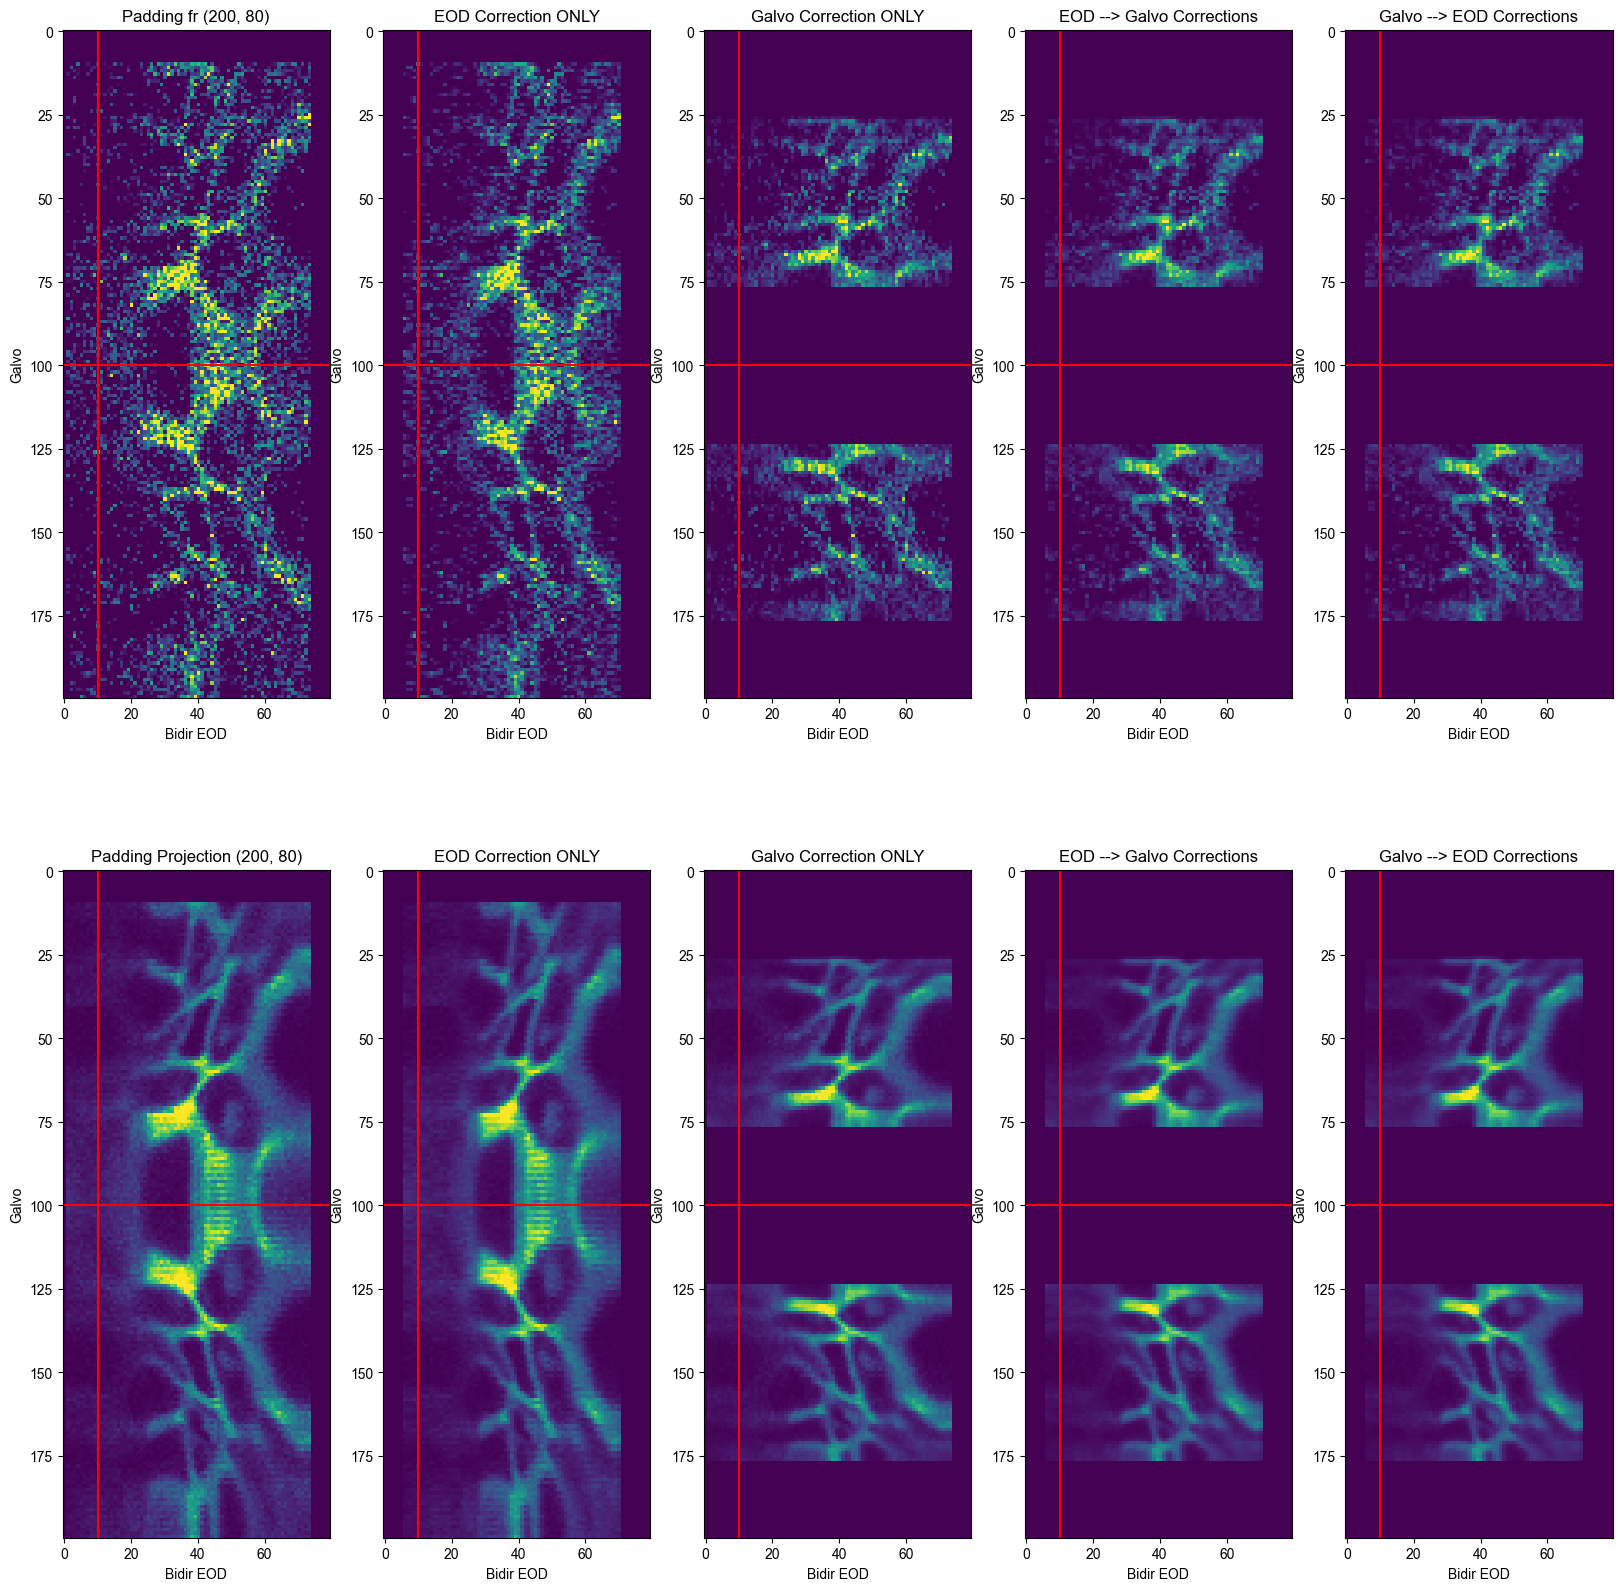

In [131]:
contrast = 0.8
nFr = data_EOD_Shifted_pad.shape[0]
##############################################################
data_EOD_Shifted_pad_EODCorr = np.zeros((nFr,finalSize[0],finalSize[1]))
for t in range(data_EOD_Shifted_pad.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    tempImg[0:EOD_bidir_turn_px,:] = 0
    # EOD_correction = forward_warp_sum(tempImg, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation, finalSize)
    EOD_correction = forward_warp_sum_unified(
        tempImg,
        EOD_correction_map_x,
        EOD_orig_map_y,
        out_shape=finalSize,
        method=EOD_interpolation,
        k=EOD_supersample,
        return_counts=True,
        dtype=np.float32)
    EOD_corrected_data = copy.deepcopy(EOD_correction[0])
    EOD_corrected_weights = copy.deepcopy(EOD_correction[1])
    if EOD_apply_weights:
        EOD_corrected_data = np.divide(EOD_corrected_data,  EOD_corrected_weights)
        EOD_corrected_data[np.isnan(EOD_corrected_data)] = 0
    # if EOD_interpolation == 'nearest':
    #     EOD_corrected_data = clean_splat(EOD_corrected_data,'x',EOD_shiftX,finalSize,mergeThresh,verbose=False)
    # data_EOD_Shifted_pad_EODCorr[t,:,:] = data_EOD_Shifted_pad_EODCorr[t,:,:] + EOD_corrected_data
    data_EOD_Shifted_pad_EODCorr[t,:,:] = EOD_corrected_data
data_EOD_Shifted_pad_EODCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_EODCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_GalvoCorr = np.zeros((nFr,finalSize[0],finalSize[1]))
for t in range(data_EOD_Shifted_pad.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    # galvo_correction = forward_warp_sum(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation,finalSize)
    galvo_correction = forward_warp_sum_unified(
        tempImg,
        galvo_orig_map_x,
        galvo_correction_map_y,
        out_shape=finalSize,
        method=galvo_interpolation,
        k=EOD_supersample,
        return_counts=True,
        dtype=np.float32)
    galvo_corrected_data = copy.deepcopy(galvo_correction[0])
    galvo_corrected_weights = copy.deepcopy(galvo_correction[1])
    if galvo_apply_weights:
        galvo_corrected_data = np.divide(galvo_corrected_data,  galvo_corrected_weights)
        galvo_corrected_data[np.isnan(galvo_corrected_data)] = 0
    # if galvo_interpolation == 'nearest':
    #     galvo_corrected_data = clean_splat(test_galvo_corrected_data,'y',galvo_shiftY,finalSize,mergeThresh,verbose=False)
    galvo_corrected_data[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    data_EOD_Shifted_pad_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_GalvoCorr[t,:,:] + galvo_corrected_data
    
    tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    galvo_correction = forward_warp_sum_unified(
        tempImg,
        galvo_orig_map_x,
        galvo_correction_map_y,
        out_shape=finalSize,
        method=galvo_interpolation,
        k=EOD_supersample,
        return_counts=True,
        dtype=np.float32)
    # galvo_correction = forward_warp_sum(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation,finalSize)
    galvo_corrected_data = copy.deepcopy(galvo_correction[0])
    galvo_corrected_weights = copy.deepcopy(galvo_correction[1])
    if galvo_apply_weights:
        galvo_corrected_data = np.divide(galvo_corrected_data,  galvo_corrected_weights)
        galvo_corrected_data[np.isnan(galvo_corrected_data)] = 0
    # if galvo_interpolation == 'nearest':
    #     galvo_corrected_data = clean_splat(test_galvo_corrected_data,'y',galvo_shiftY,finalSize,mergeThresh,verbose=False)
    galvo_corrected_data[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_GalvoCorr[t,:,:] + galvo_corrected_data
data_EOD_Shifted_pad_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_GalvoCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_EODCorr_GalvoCorr = np.zeros((nFr,finalSize[0],finalSize[1]))
for t in range(data_EOD_Shifted_pad.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_EODCorr[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    # galvo_correction = forward_warp_sum(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation,finalSize)
    galvo_correction = forward_warp_sum_unified(
        tempImg,
        galvo_orig_map_x,
        galvo_correction_map_y,
        out_shape=finalSize,
        method=galvo_interpolation,
        k=EOD_supersample,
        return_counts=True,
        dtype=np.float32)
    galvo_corrected_data = copy.deepcopy(galvo_correction[0])
    galvo_corrected_weights = copy.deepcopy(galvo_correction[1])
    if galvo_apply_weights:
        galvo_corrected_data = np.divide(galvo_corrected_data,  galvo_corrected_weights)
        galvo_corrected_data[np.isnan(galvo_corrected_data)] = 0
    # if galvo_interpolation == 'nearest':
    #     galvo_corrected_data = clean_splat(test_galvo_corrected_data,'y',galvo_shiftY,finalSize,mergeThresh,verbose=False)
    galvo_corrected_data[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] + galvo_corrected_data
    #################################################
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_EODCorr[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    # galvo_correction = forward_warp_sum(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation,finalSize)
    galvo_correction = forward_warp_sum_unified(
        tempImg,
        galvo_orig_map_x,
        galvo_correction_map_y,
        out_shape=finalSize,
        method=galvo_interpolation,
        k=EOD_supersample,
        return_counts=True,
        dtype=np.float32)
    galvo_corrected_data = copy.deepcopy(galvo_correction[0])
    galvo_corrected_weights = copy.deepcopy(galvo_correction[1])
    if galvo_apply_weights:
        galvo_corrected_data = np.divide(galvo_corrected_data,  galvo_corrected_weights)
        galvo_corrected_data[np.isnan(galvo_corrected_data)] = 0
    # if galvo_interpolation == 'nearest':
    #     galvo_corrected_data = clean_splat(test_galvo_corrected_data,'y',galvo_shiftY,finalSize,mergeThresh,verbose=False)

    galvo_corrected_data[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] + galvo_corrected_data  
data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_EODCorr_GalvoCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_GalvoCorr_EODCorr = np.zeros((nFr,finalSize[0],finalSize[1]))
for t in range(data_EOD_Shifted_pad.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_GalvoCorr[t,:,:])
    tempImg[0:EOD_bidir_turn_px,:] = 0
    # EOD_correction = forward_warp_sum(tempImg, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation, finalSize)
    EOD_correction = forward_warp_sum_unified(
        tempImg,
        EOD_correction_map_x,
        EOD_orig_map_y,
        out_shape=finalSize,
        method=EOD_interpolation,
        k=EOD_supersample,
        return_counts=True,
        dtype=np.float32)

    
    EOD_corrected_data = copy.deepcopy(EOD_correction[0])
    EOD_corrected_weights = copy.deepcopy(EOD_correction[1])
    if EOD_apply_weights:
        EOD_corrected_data = np.divide(EOD_corrected_data,  EOD_corrected_weights)
        EOD_corrected_data[np.isnan(EOD_corrected_data)] = 0
    # if EOD_interpolation == 'nearest':
    #     EOD_corrected_data = clean_splat(EOD_corrected_data,'x',EOD_shiftX,finalSize,mergeThresh,verbose=False)
    # data_EOD_Shifted_pad_GalvoCorr_EODCorr[t,:,:] = data_EOD_Shifted_pad_GalvoCorr_EODCorr[t,:,:] + EOD_corrected_data
    data_EOD_Shifted_pad_GalvoCorr_EODCorr[t,:,:] = EOD_corrected_data
data_EOD_Shifted_pad_GalvoCorr_EODCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_GalvoCorr_EODCorr,axis=0)
##############################################################
fr = 0
fig,ax = plt.subplots(2,5,figsize = (20,20))
maxVal = np.nanmax(data_EOD_Shifted_pad_GalvoCorr_EODCorr[fr,:,:])*contrast
minVal = 0

row = 0
ax[row,0].imshow(data_EOD_Shifted_pad[fr,:,:],interpolation='none',vmin=minVal,vmax=maxVal)
ax[row,0].set_ylabel("Galvo")
ax[row,0].set_xlabel("Bidir EOD")
ax[row,0].set_title("Padding fr "+str(data_EOD_Shifted_pad[fr,:,:].shape))
ax[row,0].axvline(EOD_bidir_turn_px,color ='r')
ax[row,0].axhline(galvo_bidir_turn_px,color ='r')
ax[row,1].imshow(data_EOD_Shifted_pad_EODCorr[fr,:,:],interpolation='none',vmin=minVal,vmax=maxVal)
ax[row,1].set_ylabel("Galvo")
ax[row,1].set_xlabel("Bidir EOD")
ax[row,1].set_title("EOD Correction ONLY")
ax[row,1].axvline(EOD_bidir_turn_px,color ='r')
ax[row,1].axhline(galvo_bidir_turn_px,color ='r')
ax[row,2].imshow(data_EOD_Shifted_pad_GalvoCorr[fr,:,:],interpolation='none',vmin=minVal,vmax=maxVal)
ax[row,2].set_ylabel("Galvo")
ax[row,2].set_xlabel("Bidir EOD")
ax[row,2].set_title("Galvo Correction ONLY")
ax[row,2].axvline(EOD_bidir_turn_px,color ='r')
ax[row,2].axhline(galvo_bidir_turn_px,color ='r')
ax[row,3].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr[fr,:,:],interpolation='none',vmin=minVal,vmax=maxVal)
ax[row,3].set_ylabel("Galvo")
ax[row,3].set_xlabel("Bidir EOD")
ax[row,3].set_title("EOD --> Galvo Corrections")
ax[row,3].axvline(EOD_bidir_turn_px,color ='r')
ax[row,3].axhline(galvo_bidir_turn_px,color ='r')
ax[row,4].imshow(data_EOD_Shifted_pad_GalvoCorr_EODCorr[fr,:,:],interpolation='none',vmin=minVal,vmax=maxVal)
ax[row,4].set_ylabel("Galvo")
ax[row,4].set_xlabel("Bidir EOD")
ax[row,4].set_title("Galvo --> EOD Corrections")
ax[row,4].axvline(EOD_bidir_turn_px,color ='r')
ax[row,4].axhline(galvo_bidir_turn_px,color ='r')

row = 1
maxVal = np.nanmax(data_EOD_Shifted_pad_GalvoCorr_EODCorr_meanProj)*contrast
minVal = 0

ax[row,0].imshow(data_EOD_Shifted_pad_meanProj,interpolation='none',vmin=minVal,vmax=maxVal)
ax[row,0].set_ylabel("Galvo")
ax[row,0].set_xlabel("Bidir EOD")
ax[row,0].set_title("Padding Projection "+str(data_EOD_Shifted_pad_meanProj.shape))
ax[row,0].axvline(EOD_bidir_turn_px,color ='r')
ax[row,0].axhline(galvo_bidir_turn_px,color ='r')
ax[row,1].imshow(data_EOD_Shifted_pad_EODCorr_meanProj,interpolation='none',vmin=minVal,vmax=maxVal)
ax[row,1].set_ylabel("Galvo")
ax[row,1].set_xlabel("Bidir EOD")
ax[row,1].set_title("EOD Correction ONLY")
ax[row,1].axvline(EOD_bidir_turn_px,color ='r')
ax[row,1].axhline(galvo_bidir_turn_px,color ='r')
ax[row,2].imshow(data_EOD_Shifted_pad_GalvoCorr_meanProj,interpolation='none',vmin=minVal,vmax=maxVal)
ax[row,2].set_ylabel("Galvo")
ax[row,2].set_xlabel("Bidir EOD")
ax[row,2].set_title("Galvo Correction ONLY")
ax[row,2].axvline(EOD_bidir_turn_px,color ='r')
ax[row,2].axhline(galvo_bidir_turn_px,color ='r')
ax[row,3].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj,interpolation='none',vmin=minVal,vmax=maxVal)
ax[row,3].set_ylabel("Galvo")
ax[row,3].set_xlabel("Bidir EOD")
ax[row,3].set_title("EOD --> Galvo Corrections")
ax[row,3].axvline(EOD_bidir_turn_px,color ='r')
ax[row,3].axhline(galvo_bidir_turn_px,color ='r')
ax[row,4].imshow(data_EOD_Shifted_pad_GalvoCorr_EODCorr_meanProj,interpolation='none',vmin=minVal,vmax=maxVal)
ax[row,4].set_ylabel("Galvo")
ax[row,4].set_xlabel("Bidir EOD")
ax[row,4].set_title("Galvo --> EOD Corrections")
ax[row,4].axvline(EOD_bidir_turn_px,color ='r')
ax[row,4].axhline(galvo_bidir_turn_px,color ='r')

# <font size="5">Cropping

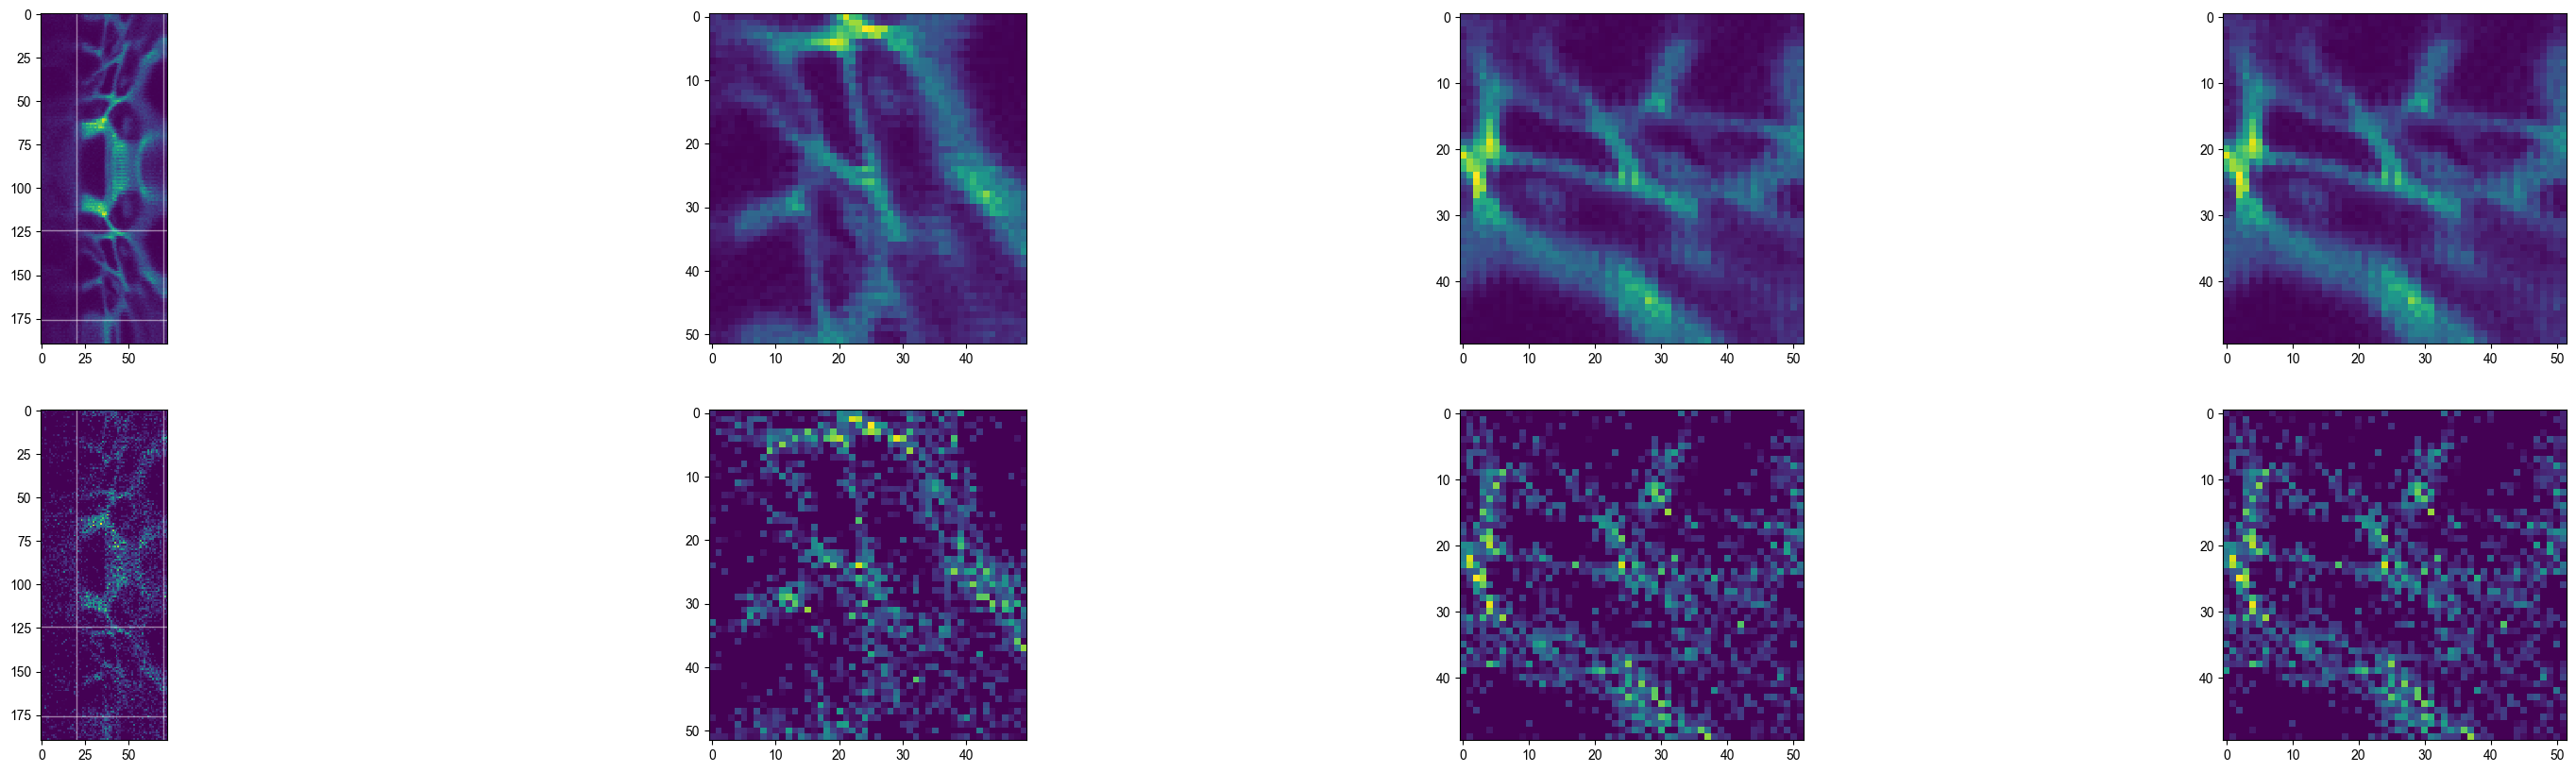

In [132]:
rotateAngle = -90

final_crop_x = [20,70]
final_crop_y = [124,176]
final_horz_scalar = 1
final_vert_scalar = 1

data_EOD_Shifted_meanProj_crop = \
    data_EOD_Shifted_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_meanProj_crop[np.isnan(data_EOD_Shifted_meanProj_crop)] = 0
data_EOD_Shifted_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
data_EOD_Shifted_crop = data_EOD_Shifted[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_crop[np.isnan(data_EOD_Shifted_crop)] = 0
data_EOD_Shifted_crop_reorient = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted.shape[0]):
    data_EOD_Shifted_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
t = 0
fig,ax = plt.subplots(2,4,figsize = (40,10))
im = ax[0,0].imshow(data_EOD_Shifted_meanProj,interpolation='none')
ax[0,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[0,1].imshow(data_EOD_Shifted_meanProj_crop,interpolation='none')
im = ax[0,2].imshow(data_EOD_Shifted_meanProj_crop_reorient,interpolation='none')
im = ax[0,3].imshow(data_EOD_Shifted_meanProj_crop_reorient_resize,interpolation='none')
im = ax[1,0].imshow(data_EOD_Shifted[t,:,:],interpolation='none')
ax[1,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[1,1].imshow(data_EOD_Shifted_crop[t,:,:],interpolation='none')
im = ax[1,2].imshow(data_EOD_Shifted_crop_reorient[t,:,:],interpolation='none')
im = ax[1,3].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],interpolation='none')


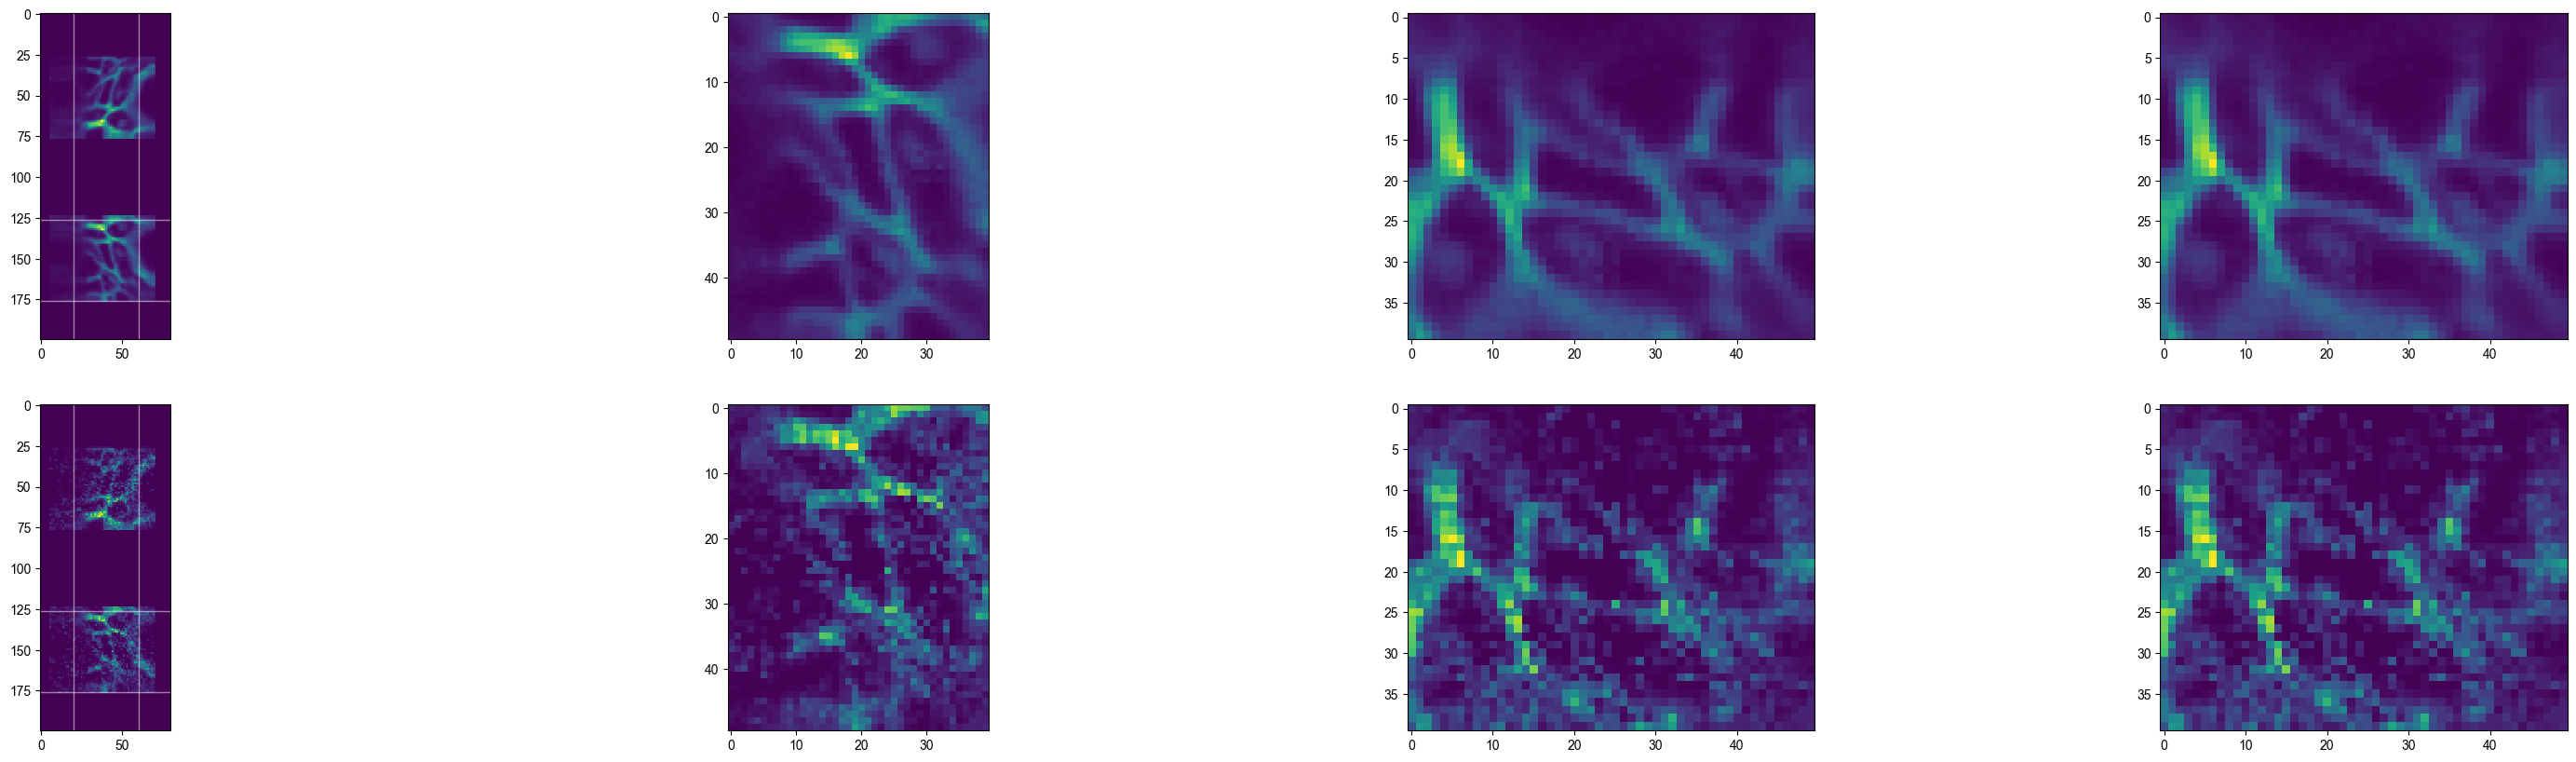

In [133]:
rotateAngle = -90

final_crop_x = [20,60]
final_crop_y = [126,176]
final_horz_scalar = 1
final_vert_scalar = 1

data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop = \
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop[np.isnan(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop)] = 0
data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop = data_EOD_Shifted_pad_EODCorr_GalvoCorr[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop[np.isnan(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop)] = 0
data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient = \
    np.ones((data_EOD_Shifted_pad_EODCorr_GalvoCorr.shape[0],\
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad_EODCorr_GalvoCorr.shape[0],\
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted_pad_EODCorr_GalvoCorr.shape[0]):
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)

t = 0
fig,ax = plt.subplots(2,4,figsize = (40,10))
im = ax[0,0].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj,interpolation='none')
ax[0,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[0,1].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop,interpolation='none')
im = ax[0,2].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient,interpolation='none')
im = ax[0,3].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj_crop_reorient_resize,interpolation='none')
im = ax[1,0].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:],interpolation='none')
ax[1,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[1,1].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop[t,:,:],interpolation='none')
im = ax[1,2].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[t,:,:],interpolation='none')
im = ax[1,3].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient_resize[t,:,:],interpolation='none')


# <font size="5">Figure

In [134]:
savePath

'/export/disk1/pooledData/ReLOAD/rhizome/'

In [135]:
data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape

(50, 40, 50)

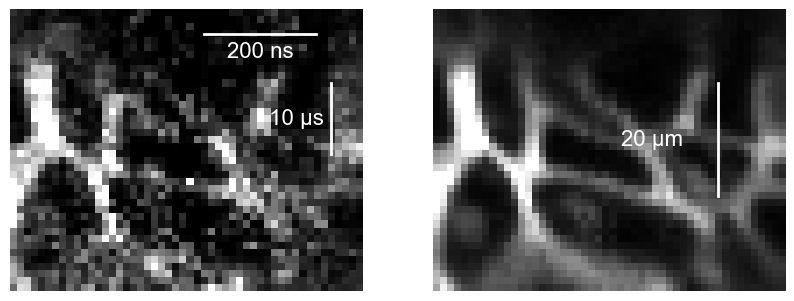

In [195]:
figDir = savePath
figName = "500kHz_100per_"+mergeLabel+".pdf"

t = 0
y_um_px = 50/40
y_um = 20
y_len = y_um/y_um_px
fontsize = 16
meanRange=list(range(0,50))
minVal = 0
maxVal = 500
fig,ax = plt.subplots(1,2,figsize = (10,10))
im = ax[0].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[t,:,:],\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[0].plot([data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-5,data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-5],[10,20],lw=1,color=(1,1,1))
ax[0].text(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-6,15,'10 μs',color=(1,1,1),fontsize=fontsize,ha='right',va='center')
ax[0].plot([data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-7,data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-23],[3,3],lw=1,color=(1,1,1))
ax[0].text(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-15,4,'200 ns',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
ax[0]=imshow_cleanup(ax[0])
im = ax[1].imshow(np.nanmean(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient[meanRange,:,:],axis=0),\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[1].plot([data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-10,data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-10],[10,10+y_len],lw=1,color=(1,1,1))
ax[1].text(data_EOD_Shifted_pad_EODCorr_GalvoCorr_crop_reorient.shape[2]-15,10+y_len/2,'20 μm',color=(1,1,1),fontsize=fontsize,ha='right',va='center')
ax[1]=imshow_cleanup(ax[1])
with PdfPages(os.path.join(figDir,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


In [109]:
[10,10+20*y_um_px]

[10, 35.0]

# <font size="5">Aaron correction

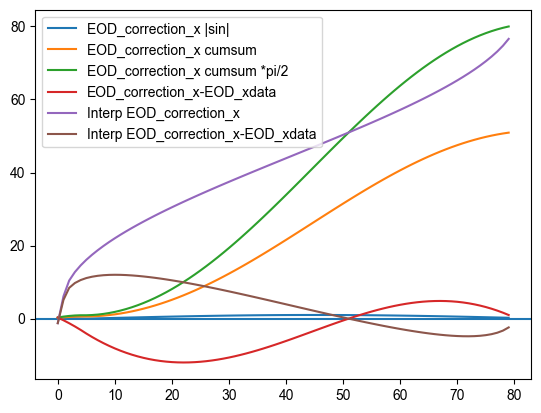

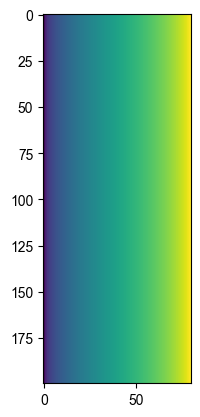

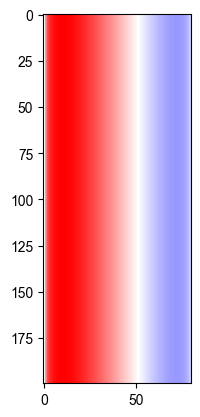

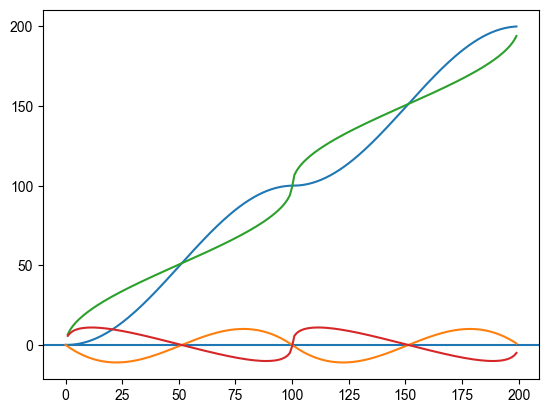

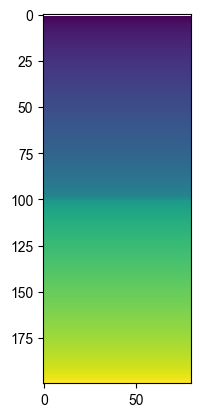

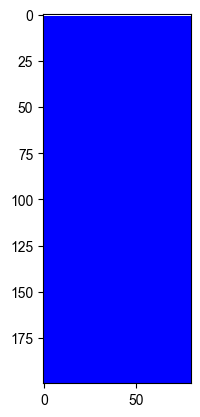

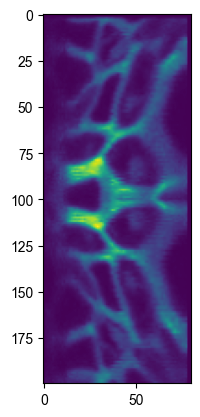

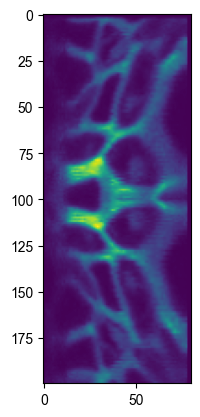

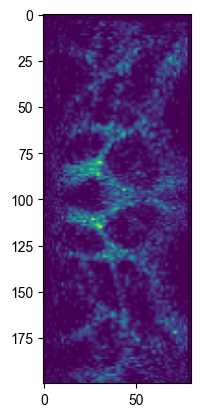

In [326]:
import scipy
import skimage

#really only two params to play with after missing lines added
EOD_correction_phase_shift_px = 5 
galvo_correction_phase_shift_px = 1 
galvo_bidir_turn_px = 100
##

#really shouldn't change
EOD_correction_freq = 0.5 
galvo_correction_freq = 1
##

EOD_xdata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[1])
h, w = data_EOD_Shifted_pad_meanProj.shape[:2]
EOD_orig_map_x, EOD_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
EOD_correction_phase_shift = (EOD_correction_phase_shift_px/w)* 2 * np.pi * EOD_correction_freq
x1_norm = ((EOD_orig_map_x) / (w)) * 2 * np.pi * EOD_correction_freq
plt.figure()
plt.axhline(0)
EOD_correction_x = np.abs(np.sin(x1_norm[0,:]-EOD_correction_phase_shift))
plt.plot(EOD_correction_x,label='EOD_correction_x |sin|')
EOD_correction_x = np.cumsum(EOD_correction_x)
plt.plot(EOD_correction_x,label='EOD_correction_x cumsum')
EOD_correction_x = EOD_correction_x*np.pi/2
plt.plot(EOD_correction_x,label='EOD_correction_x cumsum *pi/2')
plt.plot(EOD_correction_x-EOD_xdata,label='EOD_correction_x-EOD_xdata')
EOD_correction_x = scipy.interpolate.interp1d(EOD_correction_x,EOD_orig_map_x[0,:],
                                                  kind='linear',fill_value='extrapolate')(EOD_orig_map_x[0,:])
plt.plot(EOD_correction_x,label='Interp EOD_correction_x')
plt.plot(EOD_correction_x-EOD_xdata,label='Interp EOD_correction_x-EOD_xdata')
EOD_correction_map_x = np.repeat(EOD_correction_x,h).reshape(h,w,order='F')
plt.legend()
plt.figure()
plt.imshow(EOD_correction_map_x)

maxDelta = np.nanmax(np.abs(EOD_correction_map_x-EOD_orig_map_x))

plt.figure()
plt.imshow(EOD_correction_map_x-EOD_orig_map_x,cmap='bwr',vmin = -maxDelta, vmax = maxDelta)

galvo_ydata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[0])
galvo_rel_ydata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[0])-galvo_bidir_turn_px
h, w = data_EOD_Shifted_pad_meanProj.shape[:2]
galvo_orig_map_x, galvo_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
galvo_correction_phase_shift = (galvo_correction_phase_shift_px/h)* 2 * np.pi * galvo_correction_freq
y1_norm = ((galvo_orig_map_y) / (h)) * 2 * np.pi * galvo_correction_freq
galvo_correction_y = np.cumsum(np.abs(np.sin(y1_norm[:,0]-galvo_correction_phase_shift)),axis=0)*np.pi/2
plt.figure()
plt.axhline(0)
plt.plot(galvo_correction_y,label='galvo_correction_y')
plt.plot(galvo_correction_y-galvo_ydata,label='galvo_correction_y-galvo_ydata')
galvo_correction_y = scipy.interpolate.interp1d(galvo_correction_y,galvo_orig_map_y[:,0],
                                                  kind='linear',fill_value='extrapolate')(galvo_orig_map_y[:,0])
plt.plot(galvo_correction_y)
plt.plot(galvo_correction_y-galvo_ydata)
galvo_correction_map_y = np.repeat(galvo_correction_y,w).reshape(w,h,order='F').T
plt.figure()
plt.imshow(galvo_correction_map_y)

maxDelta = np.nanmax(np.abs(galvo_correction_map_y-galvo_orig_map_y))
plt.figure()
plt.imshow(galvo_correction_map_y-galvo_orig_map_y,cmap='bwr',vmin = -maxDelta, vmax = maxDelta)


tmap=np.dstack([galvo_correction_map_y, EOD_correction_map_x]).transpose([2,0,1])
data_EOD_Shifted_pad_meanProj_fullCorr = skimage.transform.warp(data_EOD_Shifted_pad_meanProj, tmap)

data_EOD_Shifted_pad_fullCorr = np.zeros_like(data_EOD_Shifted_pad)
for t in range(data_EOD_Shifted_pad.shape[0]):
    data_EOD_Shifted_pad_fullCorr[t,:,:] = skimage.transform.warp(data_EOD_Shifted_pad[t,:,:], tmap)
data_EOD_Shifted_pad_fullCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_fullCorr,axis=0)


plt.figure()
plt.imshow(data_EOD_Shifted_pad_meanProj_fullCorr)
plt.figure()
plt.imshow(data_EOD_Shifted_pad_fullCorr_meanProj)
plt.figure()
plt.imshow(data_EOD_Shifted_pad_fullCorr[t,:,:])


# <font size="5">Cropping

In [327]:
data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient.shape

(67, 101)

(90, 101)


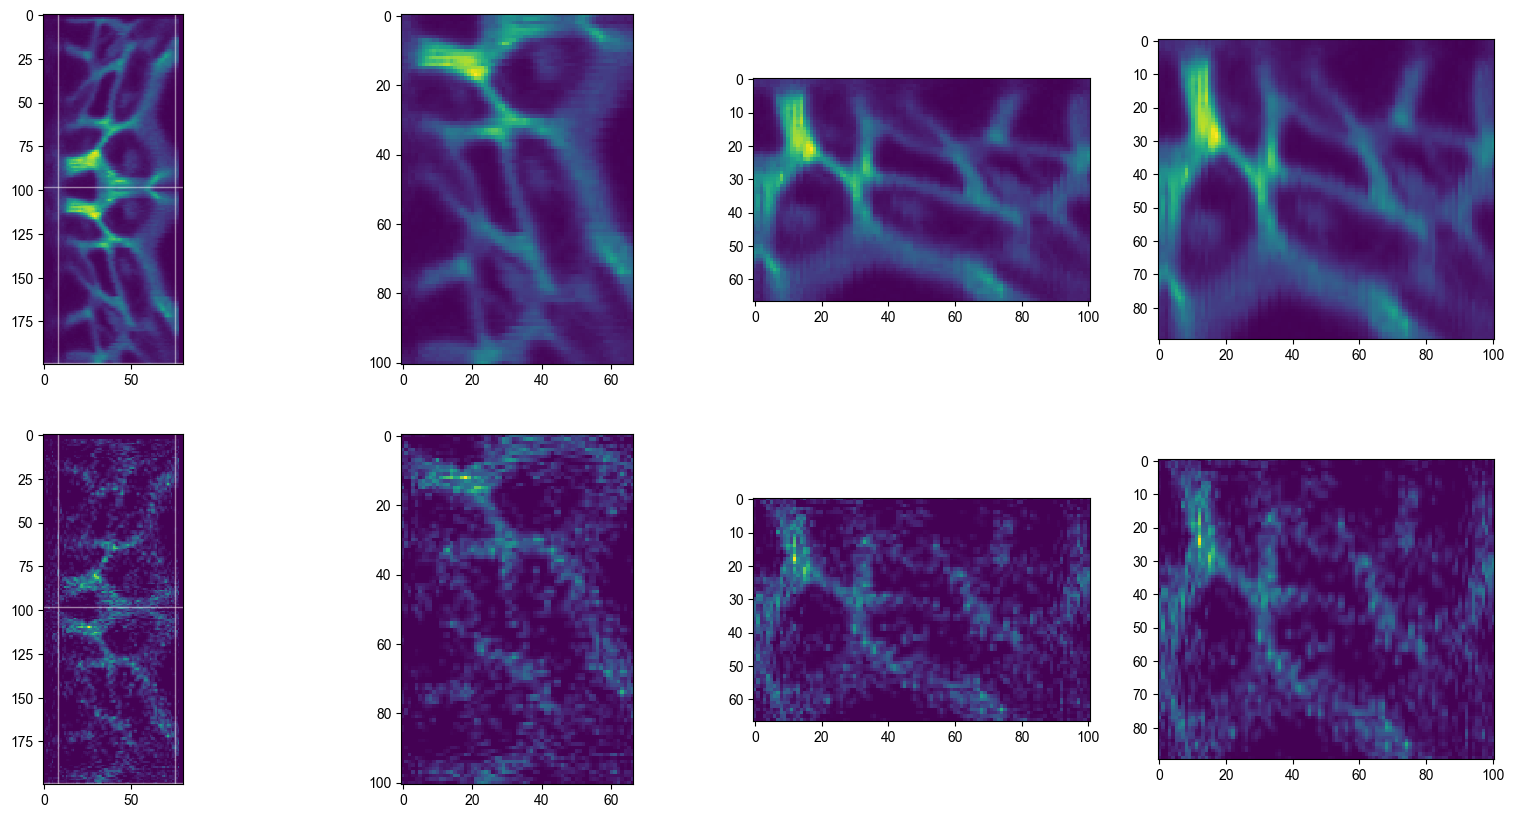

In [328]:
rotateAngle = -90

final_crop_x = [8,75]
final_crop_y = [98,199]
final_horz_scalar = 1
final_vert_scalar = 1.35

data_EOD_Shifted_pad_fullCorr_meanProj_crop = \
    data_EOD_Shifted_pad_fullCorr_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_fullCorr_meanProj_crop[np.isnan(data_EOD_Shifted_pad_fullCorr_meanProj_crop)] = 0

data_EOD_Shifted_pad_fullCorr_crop = \
    data_EOD_Shifted_pad_fullCorr[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_fullCorr_crop[np.isnan(data_EOD_Shifted_pad_fullCorr_crop)] = 0

data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_pad_fullCorr_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
print(data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient_resize.shape)
data_EOD_Shifted_pad_fullCorr_crop_reorient = \
    np.ones((data_EOD_Shifted_pad_fullCorr.shape[0],\
    data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_pad_fullCorr_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad_fullCorr.shape[0],\
    data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted_pad_fullCorr.shape[0]):
    data_EOD_Shifted_pad_fullCorr_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_pad_fullCorr_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_pad_fullCorr_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_pad_fullCorr_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)

t = 0
fig,ax = plt.subplots(2,4,figsize = (20,10))
row = 0
im = ax[row,0].imshow(data_EOD_Shifted_pad_fullCorr_meanProj,interpolation='none')
ax[row,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[row,1].imshow(data_EOD_Shifted_pad_fullCorr_meanProj_crop,interpolation='none')
im = ax[row,2].imshow(data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient,interpolation='none')
im = ax[row,3].imshow(data_EOD_Shifted_pad_fullCorr_meanProj_crop_reorient_resize,interpolation='none')
row = 1
im = ax[row,0].imshow(data_EOD_Shifted_pad_fullCorr[t,:,:],interpolation='none')
ax[row,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[row,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[row,1].imshow(data_EOD_Shifted_pad_fullCorr_crop[t,:,:],interpolation='none')
im = ax[row,2].imshow(data_EOD_Shifted_pad_fullCorr_crop_reorient[t,:,:],interpolation='none')
im = ax[row,3].imshow(data_EOD_Shifted_pad_fullCorr_crop_reorient_resize[t,:,:],interpolation='none')


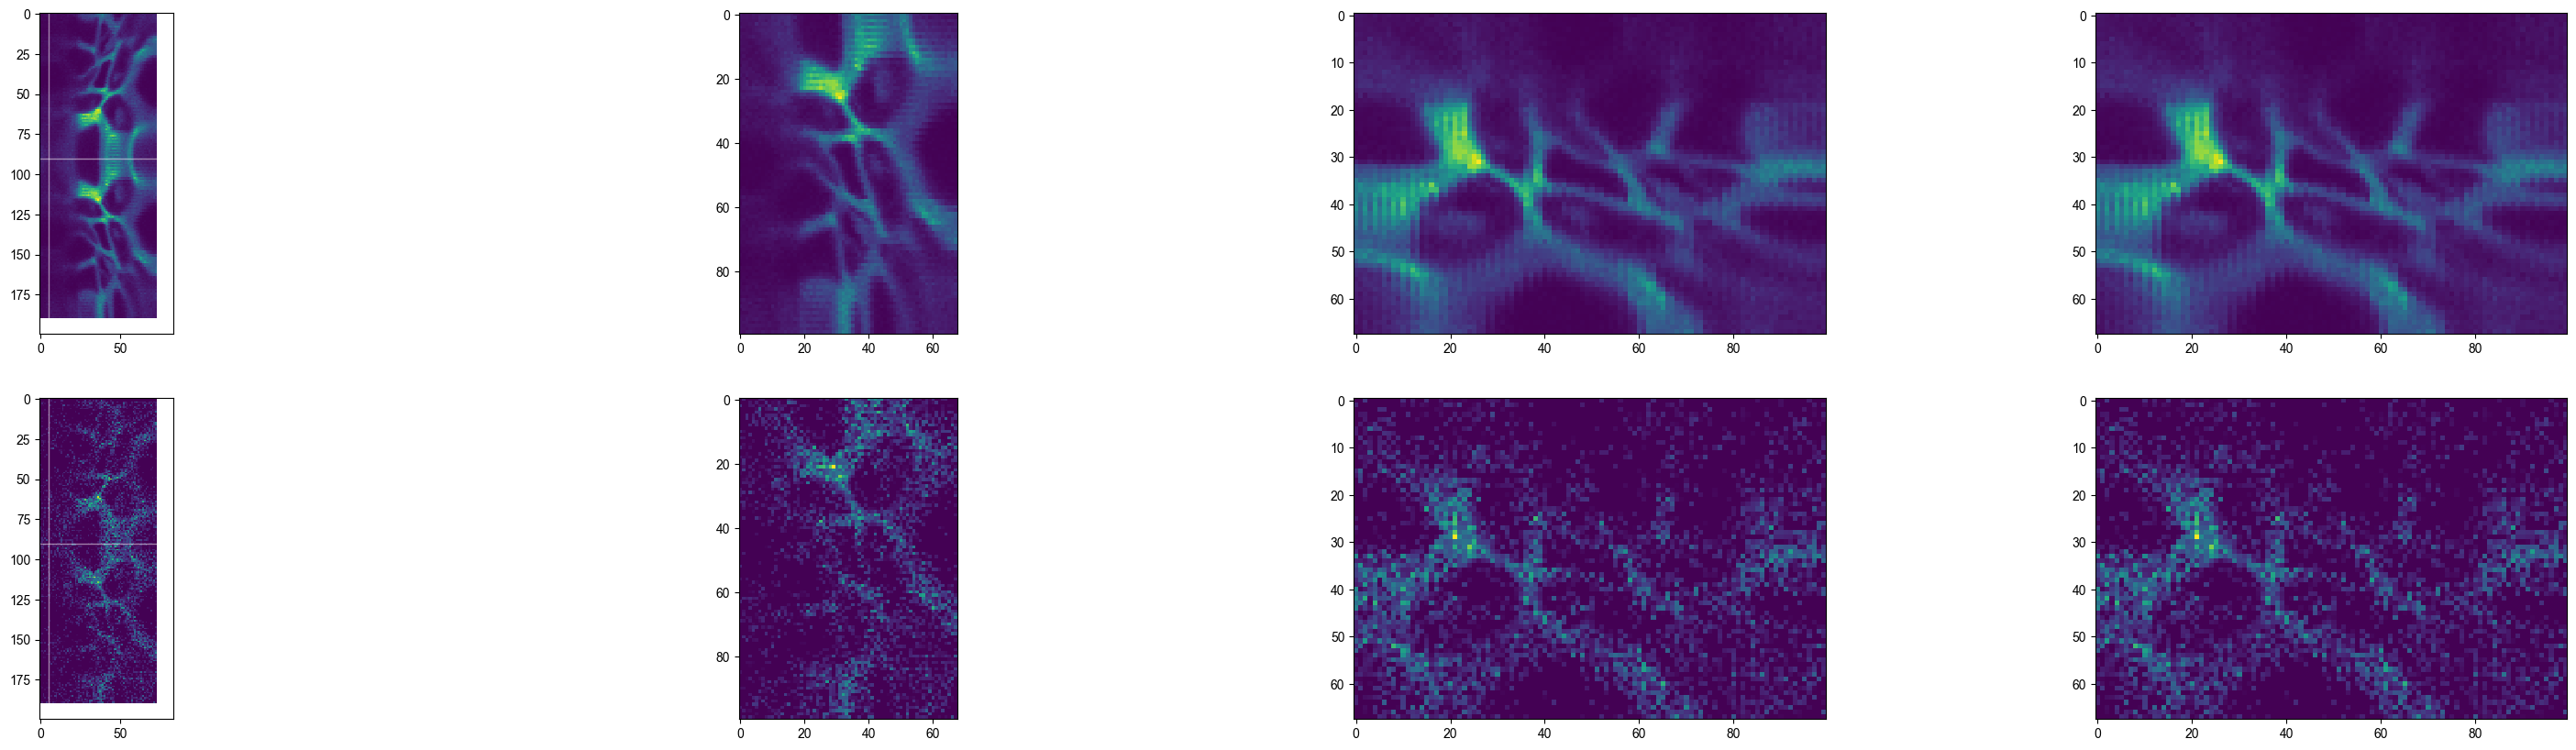

In [329]:
rotateAngle = -90

final_crop_x = [5,79]
final_crop_y = [90,190]
final_horz_scalar = 1
final_vert_scalar = 1

data_EOD_Shifted_meanProj_crop = \
    data_EOD_Shifted_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_meanProj_crop[np.isnan(data_EOD_Shifted_meanProj_crop)] = 0
data_EOD_Shifted_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
data_EOD_Shifted_crop = data_EOD_Shifted[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_crop[np.isnan(data_EOD_Shifted_crop)] = 0
data_EOD_Shifted_crop_reorient = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted.shape[0]):
    data_EOD_Shifted_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
t = 0
fig,ax = plt.subplots(2,4,figsize = (40,10))
im = ax[0,0].imshow(data_EOD_Shifted_meanProj,interpolation='none')
ax[0,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[0,1].imshow(data_EOD_Shifted_meanProj_crop,interpolation='none')
im = ax[0,2].imshow(data_EOD_Shifted_meanProj_crop_reorient,interpolation='none')
im = ax[0,3].imshow(data_EOD_Shifted_meanProj_crop_reorient_resize,interpolation='none')
im = ax[1,0].imshow(data_EOD_Shifted[t,:,:],interpolation='none')
ax[1,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[1,1].imshow(data_EOD_Shifted_crop[t,:,:],interpolation='none')
im = ax[1,2].imshow(data_EOD_Shifted_crop_reorient[t,:,:],interpolation='none')
im = ax[1,3].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],interpolation='none')


%Saturated = 2.1
%Saturated = 1.2
53
%Saturated = 0.8


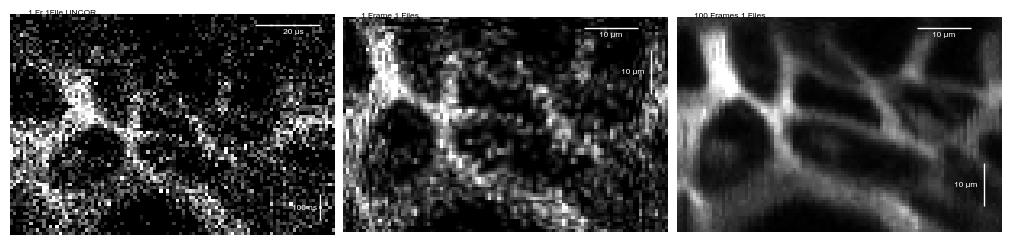

In [360]:
figDir = savePath
figName = "500kHz_100per_"+mergeLabel+".pdf"

EO_scaling_ns = 12.5
Galvo_scaling_us = 1

y_ns = 100
yy_len_px = y_ns/EO_scaling_ns

x_us = 20
xx_len_px = x_us/Galvo_scaling_us


t = 0
y_um_px = 50/data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[1]
y_um = 10
y_len_px = y_um/y_um_px

x_um_px = 60/data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]
x_um = 10
x_len_px = x_um/x_um_px

figsize = (3,3)
figsize = (10,10)
fontsize = 6
meanRange=list(range(0,50))
fig,ax=sled_general_tools.clean_subplots(1,3,figsize = figsize,constrained_layout=True)

col = 0
minVal = 0
maxVal = 700
img = copy.deepcopy(data_EOD_Shifted_crop_reorient_resize[t,:,:])
perSat = np.nansum(img>maxVal)/(img.shape[0]*img.shape[1])*100
print(f'%Saturated = {perSat:.1f}')
im = ax[col].imshow(img,\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')

#vert/EO
ax[col].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-5,data_EOD_Shifted_crop_reorient_resize.shape[2]-5],[55,55+yy_len_px],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-6,55+yy_len_px/2,str(y_ns)+' ns',color=(1,1,1),fontsize=fontsize,ha='right',va='center')

ax[col].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-5,data_EOD_Shifted_crop_reorient_resize.shape[2]-5-xx_len_px],[3,3],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-5-x_len_px/2,4,str(x_us)+' μs',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
ax[col].text(5,0,"1 Fr "+str(nFiles2Load)+"File UNCOR",color=(0,0,0),fontsize=fontsize,ha='left',va='bottom')
ax[col]=imshow_cleanup(ax[col])


col = 1
minVal = 0
maxVal = 700
img = copy.deepcopy(data_EOD_Shifted_pad_fullCorr_crop_reorient[t,:,:])
perSat = np.nansum(img>maxVal)/(img.shape[0]*img.shape[1])*100
print(f'%Saturated = {perSat:.1f}')
im = ax[col].imshow(img,\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[col].plot([data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-6,data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-6],[10,10+y_len_px],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-8,10+y_len_px/2,'10 μm',color=(1,1,1),fontsize=fontsize,ha='right',va='center')

ax[col].plot([data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10,data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10-x_len_px],[3,3],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10-x_len_px/2,4,'10 μm',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
ax[col].text(5,0,"1 Frame "+str(nFiles2Load)+" Files",color=(0,0,0),fontsize=fontsize,ha='left',va='bottom')
ax[col]=imshow_cleanup(ax[col])

col = 2
minVal = 0
maxVal = 700
img = copy.deepcopy(np.nanmean(data_EOD_Shifted_pad_fullCorr_crop_reorient[meanRange,:,:],axis=0))
perSat = np.nansum(img>maxVal)/(img.shape[0]*img.shape[1])*100
print(np.nansum(img>maxVal))
print(f'%Saturated = {perSat:.1f}')
im = ax[col].imshow(img,\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[col].plot([data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-6,data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-6],[45,45+y_len_px],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-8,45+y_len_px/2,'10 μm',color=(1,1,1),fontsize=fontsize,ha='right',va='center')

ax[col].plot([data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10,data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10-x_len_px],[3,3],lw=1,color=(1,1,1),solid_capstyle='butt')
ax[col].text(data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[2]-10-x_len_px/2,4,'10 μm',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
ax[col].text(5,0,str(data_EOD_Shifted_pad_fullCorr_crop_reorient.shape[0])+" Frames "+str(nFiles2Load)+" Files",color=(0,0,0),fontsize=fontsize,ha='left',va='bottom')
ax[col]=imshow_cleanup(ax[col])
with PdfPages(os.path.join(figDir,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


In [335]:
200/(23-7)

12.5

# <font size="5">Figure

In [289]:
figDir = savePath
figName = 'Fig6.pdf'

NameError: name 'data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient' is not defined

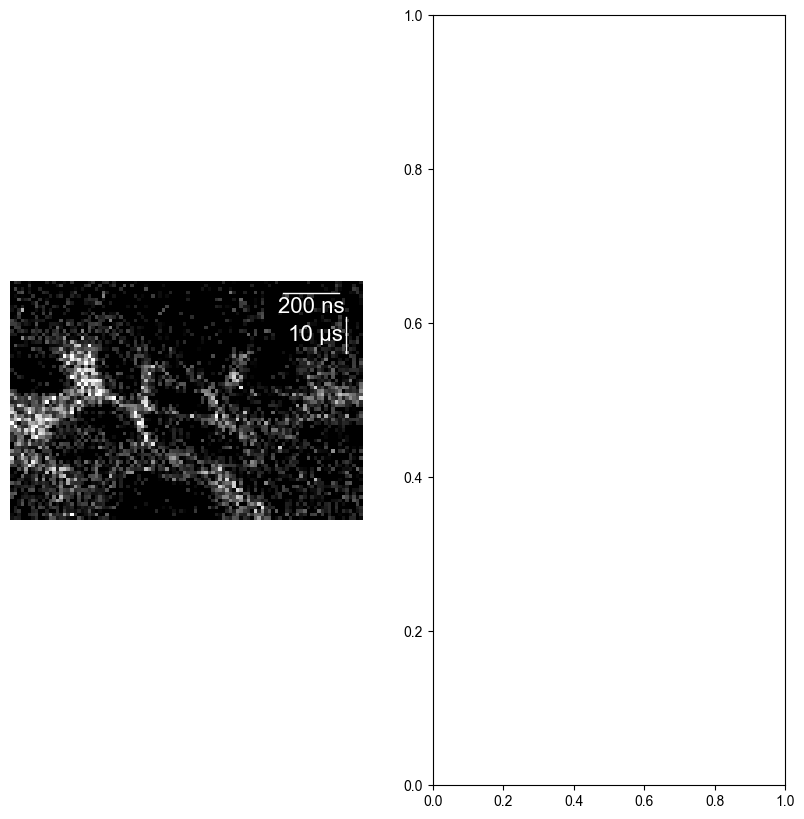

In [290]:
t = 0
y_um_px = 148.75/856.8
fontsize = 16
meanRange=list(range(0,100))
minVal = 0
maxVal = 1000
fig,ax = plt.subplots(1,2,figsize = (10,10))
im = ax[0].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[0].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-5,data_EOD_Shifted_crop_reorient_resize.shape[2]-5],[10,20],lw=1,color=(1,1,1))
ax[0].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-6,15,'10 μs',color=(1,1,1),fontsize=fontsize,ha='right',va='center')
ax[0].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-7,data_EOD_Shifted_crop_reorient_resize.shape[2]-23],[3,3],lw=1,color=(1,1,1))
ax[0].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-15,4,'200 ns',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
ax[0]=imshow_cleanup(ax[0])
im = ax[1].imshow(np.nanmean(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient[meanRange,:,:],axis=0),\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[1].plot([data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-10,data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-10],[10,34],lw=1,color=(1,1,1))
ax[1].text(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-15,22,'20 μm',color=(1,1,1),fontsize=fontsize,ha='right',va='center')
ax[1]=imshow_cleanup(ax[1])
with PdfPages(os.path.join(figDir,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


In [ ]:
imwrite(os.path.join(savePath,"data_EOD_Shifted_pad_EODCorr.tif"),data_EOD_Shifted_pad_EODCorr)
imwrite(os.path.join(savePath,"data_EOD_Shifted_pad_GalvoCorr_EODCorr.tif"),data_EOD_Shifted_pad_GalvoCorr_EODCorr)


# <font size="5">EOD and Galvo Corrections

In [ ]:
EOD_Upscale = 5
Galvo_Upscale = 5
temp = cv2.resize(data_EOD_Shifted_pad_meanProj, (0,0), fx=EOD_Upscale, fy=Galvo_Upscale)
data_EOD_Shifted_pad_Up = np.ones((data_EOD_Shifted_pad.shape[0],temp.shape[0],temp.shape[1]))*np.nan
for t in range(data_EOD_Shifted_pad.shape[0]):
    data_EOD_Shifted_pad_Up[t,:,:] = cv2.resize(data_EOD_Shifted_pad[t,:,:], (0,0), fx=EOD_Upscale, fy=Galvo_Upscale)
data_EOD_Shifted_pad_Up_meanProj = np.nanmean(data_EOD_Shifted_pad_Up,axis=0)


In [ ]:

EOD_bidir_turn_px = 5*EOD_Upscale
EOD_distortion_factor = 0.2 * np.array([-1, 1])
EOD_correction_freq = 0.5
EOD_phase_shift = True
EOD_correction_phase_shift_px = 5*EOD_Upscale
EOD_correction_shift_px = 0
EOD_distortion = 'sin' #cos
EOD_interpolation = 'bilinear'
EOD_interpolation = 'nearest'
EOD_shiftX = 5*EOD_Upscale

galvo_bidir_turn_px = 100*Galvo_Upscale
galvo_distortion_factor = 0.1 * np.array([-1, 1, -1, 1])
galvo_correction_freq = 0.9
galvo_phase_shift = True
galvo_correction_phase_shift_px = -12*Galvo_Upscale
galvo_correction_shift_px = 0
galvo_distortion = 'sin' #cos
galvo_interpolation = 'bilinear'
galvo_interpolation = 'nearest'
galvo_shiftY = 20*Galvo_Upscale

finalSize = [200*Galvo_Upscale,80*EOD_Upscale]
mergeThresh = 0


In [ ]:
EOD_xdata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[1])
EOD_rel_xdata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[1])-EOD_bidir_turn_px
h, w = data_EOD_Shifted_pad_Up_meanProj.shape[:2]
EOD_orig_map_x, EOD_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if EOD_phase_shift:
    EOD_correction_phase_shift = (EOD_correction_phase_shift_px/w)* 2 * np.pi * EOD_correction_freq
    print(f'EOD_correction_phase_shift = {EOD_correction_phase_shift}')
else:
    EOD_correction_phase_shift = 0
x1_norm = ((EOD_orig_map_x) / (w)) * 2 * np.pi * EOD_correction_freq
if EOD_distortion == 'sin':
    EOD_distortion_field = np.sin(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.sin(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.cos(x1_norm[0,:]-EOD_correction_phase_shift) * -1
else:
    EOD_distortion_field = np.cos(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.cos(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.sin(x1_norm[0,:]-EOD_correction_phase_shift) * -1
##############################################################
EOD_distortion_field = np.absolute(np.absolute(EOD_distortion_field)-w)
# EOD_distortion_field = (EOD_distortion_field - np.nanmax(EOD_distortion_field))
EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] = EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] * EOD_distortion_factor[0]
EOD_distortion_field[:,np.nanargmax(EOD_speed):w] = EOD_distortion_field[:,np.nanargmax(EOD_speed):w] * EOD_distortion_factor[1]
# EOD_distortion_field[:,int(w/2):np.nanargmin(EOD_speed)] = EOD_distortion_field[:,int(w/2):np.nanargmin(EOD_speed)] * EOD_distortion_factor[2]
# EOD_distortion_field[:,np.nanargmin(EOD_speed):w] = EOD_distortion_field[:,np.nanargmin(EOD_speed):w] * EOD_distortion_factor[3]
EOD_correction_map = EOD_orig_map_x + EOD_distortion_field
EOD_correction_map_x = EOD_correction_map.astype(np.float32)
EOD_orig_map_y = EOD_orig_map_y.astype(np.float32)
test_EOD_correction = forward_warp_sum(data_EOD_Shifted_pad_Up_meanProj, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
test_EOD_corrected_data = copy.deepcopy(test_EOD_correction[0])
test_EOD_corrected_weights = copy.deepcopy(test_EOD_correction[1])
if EOD_interpolation == 'nearest':
    test_EOD_corrected_data = clean_splat(test_EOD_corrected_data,'x',EOD_shiftX,finalSize,mergeThresh,verbose=False)
    
EOD_distortion_correction = EOD_orig_map_x-EOD_correction_map_x
# EOD_distortion_correction = np.round(EOD_distortion_correction)
EOD_correction_map_x = EOD_orig_map_x + EOD_distortion_correction
##############################################################
galvo_ydata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[0])
galvo_rel_ydata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[0])-galvo_bidir_turn_px
h, w = data_EOD_Shifted_pad_Up_meanProj.shape[:2]
galvo_orig_map_x, galvo_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if galvo_phase_shift:
    galvo_correction_phase_shift = (galvo_correction_phase_shift_px/h)* 2 * np.pi * galvo_correction_freq
    print(f'galvo_correction_phase_shift = {galvo_correction_phase_shift}')
else:
    galvo_correction_phase_shift = 0
y1_norm = ((galvo_orig_map_y) / (h)) * 2 * np.pi * galvo_correction_freq
if galvo_distortion == 'sin':
    galvo_distortion_field = np.sin(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.sin(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.cos(y1_norm[:,0]-galvo_correction_phase_shift) * -1
else:
    galvo_distortion_field = np.cos(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.cos(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.sin(y1_norm[:,0]-galvo_correction_phase_shift) * -1
##############################################################
galvo_distortion_field = np.absolute(np.absolute(galvo_distortion_field)-h)
# galvo_distortion_field = (galvo_distortion_field - np.nanmax(galvo_distortion_field))
galvo_distortion_field[0:np.nanargmax(galvo_speed),:] = galvo_distortion_field[0:np.nanargmax(galvo_speed),:] * galvo_distortion_factor[0]
galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] = galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] * galvo_distortion_factor[1]
galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] = galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] * galvo_distortion_factor[2]
galvo_distortion_field[np.nanargmin(galvo_speed):h,:] = galvo_distortion_field[np.nanargmin(galvo_speed):h,:] * galvo_distortion_factor[3]
galvo_correction_map = galvo_orig_map_y + galvo_distortion_field
galvo_correction_map_y = galvo_correction_map.astype(np.float32)
galvo_orig_map_x = galvo_orig_map_x.astype(np.float32)
test_galvo_correction = forward_warp_sum(data_EOD_Shifted_pad_Up_meanProj, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
test_galvo_corrected_data = copy.deepcopy(test_galvo_correction[0])
test_galvo_corrected_weights = copy.deepcopy(test_galvo_correction[1])
if galvo_interpolation == 'nearest':
    test_galvo_corrected_data = clean_splat(test_galvo_corrected_data,'y',galvo_shiftY,finalSize,mergeThresh,verbose=False)

galvo_distortion_correction = galvo_orig_map_y-galvo_correction_map_y
# galvo_distortion_correction = np.round(galvo_distortion_correction)
galvo_correction_map_y = galvo_orig_map_y + galvo_distortion_correction


max_distortion_correction = np.max([np.max(np.absolute(EOD_distortion_correction)), np.max(np.absolute(galvo_distortion_correction))])
##############################################################
fig,ax = plt.subplots(2,5,figsize = (20,10))
ax[0,0].plot(EOD_xdata,EOD_angle,label='Angle')
ax[0,0].plot(EOD_xdata,EOD_speed,label='Speed')
ax[0,0].axhline(-1,color = (0.5,0.5,0.5))
ax[0,0].axhline(0,color = (0,0,0))
ax[0,0].axhline(1,color = (0.5,0.5,0.5))
ax[0,0].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),label='EOD Turn')
ax[0,0].legend()
ax[0,0].set_xlim([-0.5,data_EOD_Shifted_pad_Up_meanProj.shape[1]+0.5])
ax[0,0].set_title('EOD Prediction')
ax[0,0].set_xlabel('Bidir EOD pixel position')
ax[0,0].set_ylabel('Relative Scan Speed/Angle (AU)')

ax[0,1].plot(EOD_xdata,EOD_distortion_field[0,:]*-1)
ax[0,1].axhline(0,color = (0,0,0))
ax[0,1].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0))
ax[0,1].set_xlim([-0.5,data_EOD_Shifted_pad_Up_meanProj.shape[1]+0.5])
ax[0,1].set_ylim([-1*max_distortion_correction,max_distortion_correction])
ax[0,1].set_title('EOD Pixel Corrections '+str(EOD_distortion_factor))
ax[0,1].set_xlabel('Bidir EOD pixel position')
ax[0,1].set_ylabel('Pixel correction magnitude (delta px)')

im = ax[0,2].imshow(EOD_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
plt.colorbar(im)
# ax[0,2].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[0,2].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[0,2].set_title('EOD Pixel Corrections')
ax[0,2].set_xlabel('Bidir EOD')
ax[0,2].set_ylabel('Galvo')
ax[0,2].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[0,2].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])

im = ax[0,3].imshow(test_EOD_corrected_weights,interpolation='none',cmap='inferno',\
           vmin=0,vmax=np.max(test_EOD_corrected_weights))
plt.colorbar(im)
# ax[0,2].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[0,3].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[0,3].set_title('EOD Pixel Correction Weights')
ax[0,3].set_xlabel('Bidir EOD')
ax[0,3].set_ylabel('Galvo')
ax[0,3].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[0,3].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])

im = ax[0,4].imshow(test_EOD_corrected_data,interpolation='none',cmap='inferno',\
           vmin=0,vmax=np.max(test_EOD_corrected_data))
plt.colorbar(im)
# ax[0,4].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[0,4].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[0,4].set_title('EOD Pixel Correction')
ax[0,4].set_xlabel('Bidir EOD')
ax[0,4].set_ylabel('Galvo')
ax[0,4].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[0,4].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])


ax[1,0].plot(galvo_angle,galvo_ydata,label='Angle')
ax[1,0].plot(galvo_speed,galvo_ydata,label='Speed')
ax[1,0].axvline(-1,color = (0.5,0.5,0.5))
ax[1,0].axvline(0,color = (0,0,0))
ax[1,0].axvline(1,color = (0.5,0.5,0.5))
ax[1,0].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2,label='Galvo Turn')
ax[1,0].legend()
ax[1,0].set_ylim([data_EOD_Shifted_pad_Up_meanProj.shape[0]+0.5,-0.5])
ax[1,0].set_title('Galvo Prediction')
ax[1,0].set_ylabel('Galvo pixel position')
ax[1,0].set_xlabel('Relative Scan Speed/Angle (AU)')

ax[1,1].plot(galvo_distortion_field[:,0]*-1,galvo_ydata)
ax[1,1].axvline(0,color = (0,0,0))
ax[1,1].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,1].set_ylim([data_EOD_Shifted_pad_Up_meanProj.shape[0]+0.5,-0.5])
ax[1,1].set_xlim([-1*max_distortion_correction,max_distortion_correction])
ax[1,1].set_title('Galvo Pixel Corrections '+str(galvo_distortion_factor))
ax[1,1].set_ylabel('Galvo pixel position')
ax[1,1].set_xlabel('Pixel correction magnitude (delta px)')

im = ax[1,2].imshow(galvo_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
ax[1,2].invert_yaxis()
plt.colorbar(im)
ax[1,2].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,2].set_title('Galvo Pixel Corrections')
ax[1,2].set_xlabel('Bidir EOD')
ax[1,2].set_ylabel('Galvo')
ax[1,2].set_xlim([-0.5,galvo_distortion_correction.shape[1]+0.5])
ax[1,2].set_ylim([galvo_distortion_correction.shape[0]+0.5,-0.5])

im = ax[1,3].imshow(test_galvo_corrected_weights,interpolation='none',cmap='inferno',\
           vmin=0,vmax=np.max(test_galvo_corrected_weights))
plt.colorbar(im)
# ax[1,2].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[1,3].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,3].set_title('Galvo Pixel Correction Weights')
ax[1,3].set_xlabel('Bidir EOD')
ax[1,3].set_ylabel('Galvo')
ax[1,3].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[1,3].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])

im = ax[1,4].imshow(test_galvo_corrected_data,interpolation='none',cmap='inferno',\
           vmin=0,vmax=np.max(test_galvo_corrected_data))
plt.colorbar(im)
# ax[1,4].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[1,4].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,4].set_title('Galvo Pixel Correction')
ax[1,4].set_xlabel('Bidir EOD')
ax[1,4].set_ylabel('Galvo')
ax[1,4].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[1,4].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])


In [ ]:
contrast = 0.95
maxVal = np.nanmax(data_EOD_Shifted_pad_Up)*contrast
minVal = 0
nFr = data_EOD_Shifted_pad_Up.shape[0]
##############################################################
data_EOD_Shifted_pad_Up_EODCorr = np.zeros((nFr,finalSize[0],finalSize[1]))
for t in range(data_EOD_Shifted_pad_Up.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up[t,:,:])
    EOD_correction = forward_warp_sum(tempImg, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation, finalSize)
    EOD_corrected_data = copy.deepcopy(EOD_correction[0])
    EOD_corrected_weights = copy.deepcopy(EOD_correction[1])
    if EOD_interpolation == 'nearest':
        EOD_corrected_data = clean_splat(EOD_corrected_data,'x',EOD_shiftX,finalSize,mergeThresh,verbose=False)
    # data_EOD_Shifted_pad_Up_EODCorr[t,:,:] = data_EOD_Shifted_pad_Up_EODCorr[t,:,:] + EOD_corrected_data
    data_EOD_Shifted_pad_Up_EODCorr[t,:,:] = EOD_corrected_data
data_EOD_Shifted_pad_Up_EODCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_Up_EODCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_Up_GalvoCorr = np.zeros((nFr,finalSize[0],finalSize[1]))
for t in range(data_EOD_Shifted_pad_Up.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    galvo_correction = forward_warp_sum(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation,finalSize)
    galvo_corrected_data = copy.deepcopy(galvo_correction[0])
    galvo_corrected_weights = copy.deepcopy(galvo_correction[1])
    if galvo_interpolation == 'nearest':
        galvo_corrected_data = clean_splat(test_galvo_corrected_data,'y',galvo_shiftY,finalSize,mergeThresh,verbose=False)
    galvo_corrected_data[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] + galvo_corrected_data
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    galvo_correction = forward_warp_sum(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation,finalSize)
    galvo_corrected_data = copy.deepcopy(galvo_correction[0])
    galvo_corrected_weights = copy.deepcopy(galvo_correction[1])
    if galvo_interpolation == 'nearest':
        galvo_corrected_data = clean_splat(test_galvo_corrected_data,'y',galvo_shiftY,finalSize,mergeThresh,verbose=False)
    galvo_corrected_data[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] + galvo_corrected_data
data_EOD_Shifted_pad_Up_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_Up_GalvoCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr = np.zeros((nFr,finalSize[0],finalSize[1]))
for t in range(data_EOD_Shifted_pad_Up.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up_EODCorr[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    galvo_correction = forward_warp_sum(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation,finalSize)
    galvo_corrected_data = copy.deepcopy(galvo_correction[0])
    galvo_corrected_weights = copy.deepcopy(galvo_correction[1])
    if galvo_interpolation == 'nearest':
        galvo_corrected_data = clean_splat(test_galvo_corrected_data,'y',galvo_shiftY,finalSize,mergeThresh,verbose=False)

    galvo_corrected_data[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] + galvo_corrected_data
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up_EODCorr[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    galvo_correction = forward_warp_sum(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation,finalSize)
    galvo_corrected_data = copy.deepcopy(galvo_correction[0])
    galvo_corrected_weights = copy.deepcopy(galvo_correction[1])
    if galvo_interpolation == 'nearest':
        galvo_corrected_data = clean_splat(test_galvo_corrected_data,'y',galvo_shiftY,finalSize,mergeThresh,verbose=False)
    galvo_corrected_data[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] + galvo_corrected_data  
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_Up_GalvoCorr_EODCorr = np.zeros((nFr,finalSize[0],finalSize[1]))
for t in range(data_EOD_Shifted_pad_Up.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:])
    EOD_correction = forward_warp_sum(tempImg, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation, finalSize)
    EOD_corrected_data = copy.deepcopy(EOD_correction[0])
    EOD_corrected_weights = copy.deepcopy(EOD_correction[1])
    if EOD_interpolation == 'nearest':
        EOD_corrected_data = clean_splat(EOD_corrected_data,'x',EOD_shiftX,finalSize,mergeThresh,verbose=False)
    # data_EOD_Shifted_pad_Up_GalvoCorr_EODCorr[t,:,:] = data_EOD_Shifted_pad_Up_GalvoCorr_EODCorr[t,:,:] + EOD_corrected_data
    data_EOD_Shifted_pad_Up_GalvoCorr_EODCorr[t,:,:] = EOD_corrected_data
data_EOD_Shifted_pad_Up_GalvoCorr_EODCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_Up_GalvoCorr_EODCorr,axis=0)
##############################################################
fig,ax = plt.subplots(1,5,figsize = (20,10))
ax[0].imshow(data_EOD_Shifted_pad_Up_meanProj,interpolation='none',vmin=minVal,vmax=maxVal)
ax[0].set_ylabel("Galvo")
ax[0].set_xlabel("Bidir EOD")
ax[0].set_title("Padding Projection "+str(data_EOD_Shifted_pad_Up_meanProj.shape))
ax[0].axvline(EOD_bidir_turn_px,color ='r')
ax[0].axhline(galvo_bidir_turn_px,color ='r')
ax[1].imshow(data_EOD_Shifted_pad_Up_EODCorr_meanProj,interpolation='none',vmin=minVal,vmax=maxVal)
ax[1].set_ylabel("Galvo")
ax[1].set_xlabel("Bidir EOD")
ax[1].set_title("EOD Correction ONLY")
ax[1].axvline(EOD_bidir_turn_px,color ='r')
ax[1].axhline(galvo_bidir_turn_px,color ='r')
ax[2].imshow(data_EOD_Shifted_pad_Up_GalvoCorr_meanProj,interpolation='none',vmin=minVal,vmax=maxVal)
ax[2].set_ylabel("Galvo")
ax[2].set_xlabel("Bidir EOD")
ax[2].set_title("Galvo Correction ONLY")
ax[2].axvline(EOD_bidir_turn_px,color ='r')
ax[2].axhline(galvo_bidir_turn_px,color ='r')
ax[3].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj,interpolation='none',vmin=minVal,vmax=maxVal)
ax[3].set_ylabel("Galvo")
ax[3].set_xlabel("Bidir EOD")
ax[3].set_title("EOD --> Galvo Corrections")
ax[3].axvline(EOD_bidir_turn_px,color ='r')
ax[3].axhline(galvo_bidir_turn_px,color ='r')
ax[4].imshow(data_EOD_Shifted_pad_Up_GalvoCorr_EODCorr_meanProj,interpolation='none',vmin=minVal,vmax=maxVal)
ax[4].set_ylabel("Galvo")
ax[4].set_xlabel("Bidir EOD")
ax[4].set_title("Galvo --> EOD Corrections")
ax[4].axvline(EOD_bidir_turn_px,color ='r')
ax[4].axhline(galvo_bidir_turn_px,color ='r')

In [ ]:
imwrite(os.path.join(savePath,"data_EOD_Shifted_pad_Up_EODCorr.tif"),data_EOD_Shifted_pad_Up_EODCorr)


In [ ]:
EOD_xdata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[1])
EOD_rel_xdata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[1])-EOD_bidir_turn_px
h, w = data_EOD_Shifted_pad_Up_meanProj.shape[:2]
EOD_orig_map_x, EOD_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if EOD_phase_shift:
    EOD_correction_phase_shift = (EOD_correction_phase_shift_px/w)* 2 * np.pi * EOD_correction_freq
    print(f'EOD_correction_phase_shift = {EOD_correction_phase_shift}')
else:
    EOD_correction_phase_shift = 0
x1_norm = ((EOD_orig_map_x) / (w)) * 2 * np.pi * EOD_correction_freq
if EOD_distortion == 'sin':
    EOD_distortion_field = np.sin(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.sin(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.cos(x1_norm[0,:]-EOD_correction_phase_shift) * -1
else:
    EOD_distortion_field = np.cos(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.cos(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.sin(x1_norm[0,:]-EOD_correction_phase_shift) * -1
##############################################################
EOD_distortion_field = np.absolute(np.absolute(EOD_distortion_field)-w)
EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] = EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] * EOD_distortion_factor[0]
EOD_distortion_field[:,np.nanargmax(EOD_speed):w] = EOD_distortion_field[:,np.nanargmax(EOD_speed):w] * EOD_distortion_factor[1]
EOD_correction_map = EOD_orig_map_x + EOD_distortion_field
EOD_correction_map_x = EOD_correction_map.astype(np.float32)
EOD_orig_map_y = EOD_orig_map_y.astype(np.float32)
data_EOD_ShiftedCorrected_meanProj = cv2.remap(data_EOD_Shifted_pad_Up_meanProj, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
EOD_distortion_correction = EOD_orig_map_x-EOD_correction_map_x
##############################################################
galvo_ydata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[0])
galvo_rel_ydata = np.arange(0,data_EOD_Shifted_pad_Up_meanProj.shape[0])-galvo_bidir_turn_px
h, w = data_EOD_Shifted_pad_Up_meanProj.shape[:2]
galvo_orig_map_x, galvo_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if galvo_phase_shift:
    galvo_correction_phase_shift = (galvo_correction_phase_shift_px/h)* 2 * np.pi * galvo_correction_freq
    print(f'galvo_correction_phase_shift = {galvo_correction_phase_shift}')
else:
    galvo_correction_phase_shift = 0
y1_norm = ((galvo_orig_map_y) / (h)) * 2 * np.pi * galvo_correction_freq
if galvo_distortion == 'sin':
    galvo_distortion_field = np.sin(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.sin(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.cos(y1_norm[:,0]-galvo_correction_phase_shift) * -1
else:
    galvo_distortion_field = np.cos(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.cos(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.sin(y1_norm[:,0]-galvo_correction_phase_shift) * -1
##############################################################
galvo_distortion_field = np.absolute(np.absolute(galvo_distortion_field)-h)
galvo_distortion_field[0:np.nanargmax(galvo_speed),:] = galvo_distortion_field[0:np.nanargmax(galvo_speed),:] * galvo_distortion_factor[0]
galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] = galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] * galvo_distortion_factor[1]
galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] = galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] * galvo_distortion_factor[2]
galvo_distortion_field[np.nanargmin(galvo_speed):h,:] = galvo_distortion_field[np.nanargmin(galvo_speed):h,:] * galvo_distortion_factor[3]
galvo_correction_map = galvo_orig_map_y + galvo_distortion_field
galvo_correction_map_y = galvo_correction_map.astype(np.float32)
galvo_orig_map_x = galvo_orig_map_x.astype(np.float32)
data_EOD_ShiftedCorrected_meanProj = cv2.remap(data_EOD_Shifted_pad_Up_meanProj, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
galvo_distortion_correction = galvo_orig_map_y-galvo_correction_map_y
max_distortion_correction = np.max([np.max(np.absolute(EOD_distortion_correction)), np.max(np.absolute(galvo_distortion_correction))])
##############################################################
fig,ax = plt.subplots(2,3,figsize = (15,10))
ax[0,0].plot(EOD_xdata,EOD_angle,label='Angle')
ax[0,0].plot(EOD_xdata,EOD_speed,label='Speed')
ax[0,0].axhline(-1,color = (0.5,0.5,0.5))
ax[0,0].axhline(0,color = (0,0,0))
ax[0,0].axhline(1,color = (0.5,0.5,0.5))
ax[0,0].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),label='EOD Turn')
ax[0,0].legend()
ax[0,0].set_xlim([-0.5,data_EOD_Shifted_pad_Up_meanProj.shape[1]+0.5])
ax[0,0].set_title('EOD Prediction')
ax[0,0].set_xlabel('Bidir EOD pixel position')
ax[0,0].set_ylabel('Relative Scan Speed/Angle (AU)')

ax[0,1].plot(EOD_xdata,EOD_distortion_field[0,:]*-1)
ax[0,1].axhline(0,color = (0,0,0))
ax[0,1].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0))
ax[0,1].set_xlim([-0.5,data_EOD_Shifted_pad_Up_meanProj.shape[1]+0.5])
ax[0,1].set_ylim([-1*max_distortion_correction,max_distortion_correction])
ax[0,1].set_title('EOD Pixel Corrections '+str(EOD_distortion_factor))
ax[0,1].set_xlabel('Bidir EOD pixel position')
ax[0,1].set_ylabel('Pixel correction magnitude (delta px)')

im = ax[0,2].imshow(EOD_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
plt.colorbar(im)
ax[0,2].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[0,2].set_title('EOD Pixel Corrections')
ax[0,2].set_xlabel('Bidir EOD')
ax[0,2].set_ylabel('Galvo')
ax[0,2].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[0,2].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])

ax[1,0].plot(galvo_angle,galvo_ydata,label='Angle')
ax[1,0].plot(galvo_speed,galvo_ydata,label='Speed')
ax[1,0].axvline(-1,color = (0.5,0.5,0.5))
ax[1,0].axvline(0,color = (0,0,0))
ax[1,0].axvline(1,color = (0.5,0.5,0.5))
ax[1,0].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2,label='Galvo Turn')
ax[1,0].legend()
ax[1,0].set_ylim([data_EOD_Shifted_pad_Up_meanProj.shape[0]+0.5,-0.5])
ax[1,0].set_title('Galvo Prediction')
ax[1,0].set_ylabel('Galvo pixel position')
ax[1,0].set_xlabel('Relative Scan Speed/Angle (AU)')

ax[1,1].plot(galvo_distortion_field[:,0]*-1,galvo_ydata)
ax[1,1].axvline(0,color = (0,0,0))
ax[1,1].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,1].set_ylim([data_EOD_Shifted_pad_Up_meanProj.shape[0]+0.5,-0.5])
ax[1,1].set_xlim([-1*max_distortion_correction,max_distortion_correction])
ax[1,1].set_title('Galvo Pixel Corrections '+str(galvo_distortion_factor))
ax[1,1].set_ylabel('Galvo pixel position')
ax[1,1].set_xlabel('Pixel correction magnitude (delta px)')

im = ax[1,2].imshow(galvo_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
ax[1,2].invert_yaxis()
plt.colorbar(im)
ax[1,2].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,2].set_title('Galvo Pixel Corrections')
ax[1,2].set_xlabel('Bidir EOD')
ax[1,2].set_ylabel('Galvo')
ax[1,2].set_xlim([-0.5,galvo_distortion_correction.shape[1]+0.5])
ax[1,2].set_ylim([galvo_distortion_correction.shape[0]+0.5,-0.5])


In [ ]:
data_EOD_Shifted_pad_Up_EODCorr = np.zeros_like(data_EOD_Shifted_pad_Up)
for t in range(data_EOD_Shifted_pad_Up.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up[t,:,:])
    tempImg = cv2.remap(tempImg, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
    data_EOD_Shifted_pad_Up_EODCorr[t,:,:] = data_EOD_Shifted_pad_Up_EODCorr[t,:,:] + tempImg
data_EOD_Shifted_pad_Up_EODCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_Up_EODCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_Up_GalvoCorr = np.zeros_like(data_EOD_Shifted_pad_Up)
for t in range(data_EOD_Shifted_pad_Up.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] + tempImg
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_GalvoCorr[t,:,:] + tempImg
data_EOD_Shifted_pad_Up_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_Up_GalvoCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr = np.zeros_like(data_EOD_Shifted_pad_Up)
for t in range(data_EOD_Shifted_pad_Up.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up_EODCorr[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad_Up.shape[1],:] = 0
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] + tempImg
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_Up_EODCorr[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:] + tempImg  
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr,axis=0)
##############################################################
fig,ax = plt.subplots(1,4,figsize = (30,10))
ax[0].imshow(data_EOD_Shifted_pad_Up_meanProj,interpolation='none')
ax[0].set_ylabel("Galvo")
ax[0].set_xlabel("Bidir EOD")
ax[0].set_title("Padding Projection "+str(data_EOD_Shifted_pad_Up_meanProj.shape))
ax[0].axvline(EOD_bidir_turn_px,color ='r')
ax[0].axhline(galvo_bidir_turn_px,color ='r')
ax[1].imshow(data_EOD_Shifted_pad_Up_EODCorr_meanProj,interpolation='none')
ax[1].set_ylabel("Galvo")
ax[1].set_xlabel("Bidir EOD")
ax[1].set_title("EOD Correction ONLY")
ax[1].axvline(EOD_bidir_turn_px,color ='r')
ax[1].axhline(galvo_bidir_turn_px,color ='r')
ax[2].imshow(data_EOD_Shifted_pad_Up_GalvoCorr_meanProj,interpolation='none')
ax[2].set_ylabel("Galvo")
ax[2].set_xlabel("Bidir EOD")
ax[2].set_title("Galvo Correction ONLY")
ax[2].axvline(EOD_bidir_turn_px,color ='r')
ax[2].axhline(galvo_bidir_turn_px,color ='r')
ax[3].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj,interpolation='none')
ax[3].set_ylabel("Galvo")
ax[3].set_xlabel("Bidir EOD")
ax[3].set_title("EOD and Galvo Corrections")
ax[3].axvline(EOD_bidir_turn_px,color ='r')
ax[3].axhline(galvo_bidir_turn_px,color ='r')

# <font size="5">Cropping

In [ ]:
rotateAngle = -90

final_crop_x = [20,60]
final_crop_y = [90,190]
final_horz_scalar = 1
final_vert_scalar = 1

data_EOD_Shifted_meanProj_crop = \
    data_EOD_Shifted_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_meanProj_crop[np.isnan(data_EOD_Shifted_meanProj_crop)] = 0
data_EOD_Shifted_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
data_EOD_Shifted_crop = data_EOD_Shifted[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_crop[np.isnan(data_EOD_Shifted_crop)] = 0
data_EOD_Shifted_crop_reorient = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted.shape[0]):
    data_EOD_Shifted_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
t = 0
fig,ax = plt.subplots(2,4,figsize = (40,10))
im = ax[0,0].imshow(data_EOD_Shifted_meanProj,interpolation='none')
ax[0,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[0,1].imshow(data_EOD_Shifted_meanProj_crop,interpolation='none')
im = ax[0,2].imshow(data_EOD_Shifted_meanProj_crop_reorient,interpolation='none')
im = ax[0,3].imshow(data_EOD_Shifted_meanProj_crop_reorient_resize,interpolation='none')
im = ax[1,0].imshow(data_EOD_Shifted[t,:,:],interpolation='none')
ax[1,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[1,1].imshow(data_EOD_Shifted_crop[t,:,:],interpolation='none')
im = ax[1,2].imshow(data_EOD_Shifted_crop_reorient[t,:,:],interpolation='none')
im = ax[1,3].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],interpolation='none')


In [ ]:
rotateAngle = -90

final_crop_x = [20*EOD_Upscale,60*EOD_Upscale]
final_crop_y = [120*Galvo_Upscale,185*Galvo_Upscale]
final_horz_scalar = 1
final_vert_scalar = 1

data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop = \
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj[final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop[np.isnan(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop)] = 0
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient = \
    np.fliplr(rotate(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop,rotateAngle,axes = (0,1)))
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient_resize = \
    cv2.resize(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient, (0,0), fx=final_horz_scalar, fy=final_vert_scalar)
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop = data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[:,final_crop_y[0]:final_crop_y[1],final_crop_x[0]:final_crop_x[1]]
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop[np.isnan(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop)] = 0
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient = \
    np.ones((data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr.shape[0],\
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient.shape[0],\
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient.shape[1]))*np.nan
data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient_resize = \
    np.ones((data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr.shape[0],\
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient_resize.shape[0],\
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient_resize.shape[1]))*np.nan
for t in range(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr.shape[0]):
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient[t,:,:] = \
        np.fliplr(rotate(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop[t,:,:],rotateAngle,axes = (0,1)))
    data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient_resize[t,:,:] = \
        cv2.resize(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient[t,:,:], (0,0), fx=final_horz_scalar, fy=final_vert_scalar)

t = 0
fig,ax = plt.subplots(2,4,figsize = (40,10))
im = ax[0,0].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj,interpolation='none')
ax[0,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[0,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[0,1].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop,interpolation='none')
im = ax[0,2].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient,interpolation='none')
im = ax[0,3].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_meanProj_crop_reorient_resize,interpolation='none')
im = ax[1,0].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr[t,:,:],interpolation='none')
ax[1,0].axvline(final_crop_x[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axvline(final_crop_x[1],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[0],lw=1,color=(1,1,1),alpha=0.5)
ax[1,0].axhline(final_crop_y[1],lw=1,color=(1,1,1),alpha=0.5)
im = ax[1,1].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop[t,:,:],interpolation='none')
im = ax[1,2].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient[t,:,:],interpolation='none')
im = ax[1,3].imshow(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient_resize[t,:,:],interpolation='none')


# <font size="5">Figure

In [ ]:
figDir = savePath
figName = 'Fig6.pdf'

In [ ]:
t = 0
y_um_px = 148.75/856.8
fontsize = 16
meanRange=list(range(0,100))
minVal = 0
maxVal = 1000
fig,ax = plt.subplots(1,2,figsize = (10,10))
im = ax[0].imshow(data_EOD_Shifted_crop_reorient_resize[t,:,:],\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[0].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-5,data_EOD_Shifted_crop_reorient_resize.shape[2]-5],[10,20],lw=1,color=(1,1,1))
ax[0].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-6,15,'10 μs',color=(1,1,1),fontsize=fontsize,ha='right',va='center')
ax[0].plot([data_EOD_Shifted_crop_reorient_resize.shape[2]-7,data_EOD_Shifted_crop_reorient_resize.shape[2]-23],[3,3],lw=1,color=(1,1,1))
ax[0].text(data_EOD_Shifted_crop_reorient_resize.shape[2]-15,4,'200 ns',color=(1,1,1),fontsize=fontsize,ha='center',va='top')
ax[0]=imshow_cleanup(ax[0])
im = ax[1].imshow(np.nanmean(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient[meanRange,:,:],axis=0),\
                    vmin = minVal,vmax = maxVal,interpolation='none',cmap = 'gray')
ax[1].plot([data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-10,data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-10],[10,34],lw=1,color=(1,1,1))
ax[1].text(data_EOD_Shifted_pad_Up_EODCorr_GalvoCorr_crop_reorient.shape[2]-15,22,'20 μm',color=(1,1,1),fontsize=fontsize,ha='right',va='center')
ax[1]=imshow_cleanup(ax[1])
with PdfPages(os.path.join(figDir,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


In [ ]:
def forward_warp_sum(src, Xf, Yf, method='bilinear', out_shape=None):
    """
    Forward-warp (push/splat) with accumulation.

    Parameters
    ----------
    src : (H, W) or (H, W, C) array
        Source image/array (float recommended).
    Xf, Yf : (H, W) float arrays
        FORWARD maps giving, for each *source* pixel center (y,x), the
        destination (x_d, y_d) coordinates in the output.
        Example: Xf[y, x], Yf[y, x] = destination coords for src[y, x].
    out_shape : (Hd, Wd) or None
        Output size. If None, the minimal box covering all mapped coords is used.
    method : {'bilinear', 'nearest'}
        Splatting kernel. 'bilinear' distributes to 4 neighbors; 'nearest' sums
        into the closest integer pixel only.

    Returns
    -------
    out : (Hd, Wd) or (Hd, Wd, C) array (float64)
        Accumulated sum image.
    counts : (Hd, Wd) array (float64)
        Sum of splat weights per pixel (useful if you'd like to normalize later).
    """
    src = np.asarray(src)
    H, W = src.shape[:2]
    C = 1 if src.ndim == 2 else src.shape[2]

    # Infer output shape if not provided
    if out_shape is None:
        x_min = np.nanmin(Xf); y_min = np.nanmin(Yf)
        x_max = np.nanmax(Xf); y_max = np.nanmax(Yf)
        Wd = int(np.ceil(x_max + 1))
        Hd = int(np.ceil(y_max + 1))
    else:
        Hd, Wd = out_shape

    out = np.zeros((Hd, Wd, C), dtype=np.float64)
    counts = np.zeros((Hd, Wd), dtype=np.float64)

    # Flatten source pixels
    if C == 1:
        vals = src.reshape(-1).astype(np.float64)
    else:
        vals = src.reshape(-1, C).astype(np.float64)

    xd = Xf.reshape(-1)
    yd = Yf.reshape(-1)

    if method == 'nearest':
        xi = np.rint(xd).astype(np.int32)
        yi = np.rint(yd).astype(np.int32)

        # Mask valid indices
        m = (xi >= 0) & (xi < Wd) & (yi >= 0) & (yi < Hd) & np.isfinite(xd) & np.isfinite(yd)
        xi = xi[m]; yi = yi[m]
        if C == 1:
            np.add.at(out[..., 0], (yi, xi), vals[m])
        else:
            for c in range(C):
                np.add.at(out[..., c], (yi, xi), vals[m, c])
        np.add.at(counts, (yi, xi), 1.0)

    elif method == 'bilinear':
        x0 = np.floor(xd).astype(np.int32)
        y0 = np.floor(yd).astype(np.int32)
        dx = xd - x0
        dy = yd - y0

        # 4 neighbors and their weights
        neigh = [
            (x0,     y0,     (1 - dx) * (1 - dy)),  # (x0, y0)
            (x0 + 1, y0,     dx       * (1 - dy)),  # (x0+1, y0)
            (x0,     y0 + 1, (1 - dx) * dy),        # (x0, y0+1)
            (x0 + 1, y0 + 1, dx       * dy)         # (x0+1, y0+1)
        ]

        for xn, yn, w in neigh:
            m = (xn >= 0) & (xn < Wd) & (yn >= 0) & (yn < Hd) & np.isfinite(w)
            xn = xn[m]; yn = yn[m]; wv = w[m]
            if C == 1:
                np.add.at(out[..., 0], (yn, xn), vals[m] * wv)
            else:
                for c in range(C):
                    np.add.at(out[..., c], (yn, xn), vals[m, c] * wv)
            np.add.at(counts, (yn, xn), wv)
    else:
        raise ValueError("method must be 'nearest' or 'bilinear'.")

    return (out[..., 0] if C == 1 else out), counts

def clean_splat(inputImg,axis,shift,finalSize,mergeThresh,verbose=True):
    finalImg = np.zeros((finalSize),dtype='float32')
    newImg = np.array([])
    if axis == 'x':
        for x in range(inputImg.shape[1]):
            if np.sum(inputImg[:,x])>mergeThresh:
                tempSlice = np.expand_dims(copy.deepcopy(inputImg[:,x]),axis=1)
                if verbose:
                    print("Orig X"+str(x)+" "+str(newImg.shape)+" "+str(tempSlice.shape))
                if len(newImg.shape)==2:
                    newImg = np.concatenate((newImg,tempSlice),axis = 1)
                else:
                    newImg = copy.deepcopy(tempSlice)
        for x in range(newImg.shape[1]):
            finalImg[:,x+shift] = newImg[:,x]
    else:
        for y in range(inputImg.shape[0]):
            if np.sum(inputImg[y,:])>mergeThresh:
                tempSlice = np.expand_dims(copy.deepcopy(inputImg[y,:]),axis=0)
                if verbose:
                    print("Orig Y"+str(y)+" "+str(newImg.shape)+" "+str(tempSlice.shape))
                if len(newImg.shape)==2:
                    newImg = np.concatenate((newImg,tempSlice),axis = 0)
                else:
                    newImg = copy.deepcopy(tempSlice)
        for y in range(newImg.shape[0]):
            finalImg[y+shift,:] = newImg[y,:]
    
    return finalImg


# <font size="5">No EOD Unfolded Correction

In [ ]:
EOD_bidir_turn_px = 80

EOD_distortion_factor = 0.4 * np.array([-1, 1])
EOD_correction_freq = 0.5
EOD_phase_shift = False
EOD_correction_phase_shift_px = 0
EOD_correction_shift_px = 0
EOD_distortion = 'sin' #cos
EOD_interpolation = cv2.INTER_LINEAR

galvo_bidir_turn_px = 100
# galvo_distortion_factor = 0.2 * np.array([-1, 1, -1, 1])
# galvo_correction_freq = 0.8
# galvo_phase_shift = True
# galvo_correction_phase_shift_px = -25
galvo_distortion_factor = 0.55 * np.array([-1, 1, -1, 1])
galvo_correction_freq = 0.9
galvo_phase_shift = True
galvo_correction_phase_shift_px = -12
galvo_correction_shift_px = 0
galvo_distortion = 'sin' #cos
galvo_interpolation = cv2.INTER_LINEAR

In [ ]:
EOD_xdata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[1])
EOD_rel_xdata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[1])-EOD_bidir_turn_px
h, w = data_EOD_Shifted_pad_meanProj.shape[:2]
EOD_orig_map_x, EOD_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if EOD_phase_shift:
    EOD_correction_phase_shift = (EOD_correction_phase_shift_px/w)* 2 * np.pi * EOD_correction_freq
    print(f'EOD_correction_phase_shift = {EOD_correction_phase_shift}')
else:
    EOD_correction_phase_shift = 0
x1_norm = ((EOD_orig_map_x) / (w)) * 2 * np.pi * EOD_correction_freq
if EOD_distortion == 'sin':
    EOD_distortion_field = np.sin(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.sin(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.cos(x1_norm[0,:]-EOD_correction_phase_shift) * -1
else:
    EOD_distortion_field = np.cos(x1_norm-EOD_correction_phase_shift) * w
    EOD_speed = np.cos(x1_norm[0,:]-EOD_correction_phase_shift)
    EOD_angle = np.sin(x1_norm[0,:]-EOD_correction_phase_shift) * -1
##############################################################
EOD_distortion_field = np.absolute(np.absolute(EOD_distortion_field)-w)
# EOD_distortion_field = (EOD_distortion_field - np.nanmax(EOD_distortion_field))
EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] = EOD_distortion_field[:,0:np.nanargmax(EOD_speed)] * EOD_distortion_factor[0]
EOD_distortion_field[:,np.nanargmax(EOD_speed):w] = EOD_distortion_field[:,np.nanargmax(EOD_speed):w] * EOD_distortion_factor[1]
# EOD_distortion_field[:,int(w/2):np.nanargmin(EOD_speed)] = EOD_distortion_field[:,int(w/2):np.nanargmin(EOD_speed)] * EOD_distortion_factor[2]
# EOD_distortion_field[:,np.nanargmin(EOD_speed):w] = EOD_distortion_field[:,np.nanargmin(EOD_speed):w] * EOD_distortion_factor[3]
EOD_correction_map = EOD_orig_map_x + EOD_distortion_field
EOD_correction_map_x = EOD_correction_map.astype(np.float32)
EOD_orig_map_y = EOD_orig_map_y.astype(np.float32)
data_EOD_ShiftedCorrected_meanProj = cv2.remap(data_EOD_Shifted_pad_meanProj, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
EOD_distortion_correction = EOD_orig_map_x-EOD_correction_map_x
##############################################################
galvo_ydata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[0])
galvo_rel_ydata = np.arange(0,data_EOD_Shifted_pad_meanProj.shape[0])-galvo_bidir_turn_px
h, w = data_EOD_Shifted_pad_meanProj.shape[:2]
galvo_orig_map_x, galvo_orig_map_y = np.meshgrid(np.arange(w), np.arange(h))
if galvo_phase_shift:
    galvo_correction_phase_shift = (galvo_correction_phase_shift_px/h)* 2 * np.pi * galvo_correction_freq
    print(f'galvo_correction_phase_shift = {galvo_correction_phase_shift}')
else:
    galvo_correction_phase_shift = 0
y1_norm = ((galvo_orig_map_y) / (h)) * 2 * np.pi * galvo_correction_freq
if galvo_distortion == 'sin':
    galvo_distortion_field = np.sin(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.sin(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.cos(y1_norm[:,0]-galvo_correction_phase_shift) * -1
else:
    galvo_distortion_field = np.cos(y1_norm-galvo_correction_phase_shift) * h
    galvo_speed = np.cos(y1_norm[:,0]-galvo_correction_phase_shift)
    galvo_angle = np.sin(y1_norm[:,0]-galvo_correction_phase_shift) * -1
##############################################################
galvo_distortion_field = np.absolute(np.absolute(galvo_distortion_field)-h)
# galvo_distortion_field = (galvo_distortion_field - np.nanmax(galvo_distortion_field))
galvo_distortion_field[0:np.nanargmax(galvo_speed),:] = galvo_distortion_field[0:np.nanargmax(galvo_speed),:] * galvo_distortion_factor[0]
galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] = galvo_distortion_field[np.nanargmax(galvo_speed):int(h/2),:] * galvo_distortion_factor[1]
galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] = galvo_distortion_field[int(h/2):np.nanargmin(galvo_speed),:] * galvo_distortion_factor[2]
galvo_distortion_field[np.nanargmin(galvo_speed):h,:] = galvo_distortion_field[np.nanargmin(galvo_speed):h,:] * galvo_distortion_factor[3]
galvo_correction_map = galvo_orig_map_y + galvo_distortion_field
galvo_correction_map_y = galvo_correction_map.astype(np.float32)
galvo_orig_map_x = galvo_orig_map_x.astype(np.float32)
data_EOD_ShiftedCorrected_meanProj = cv2.remap(data_EOD_Shifted_pad_meanProj, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
galvo_distortion_correction = galvo_orig_map_y-galvo_correction_map_y
max_distortion_correction = np.max([np.max(np.absolute(EOD_distortion_correction)), np.max(np.absolute(galvo_distortion_correction))])
##############################################################
fig,ax = plt.subplots(2,3,figsize = (15,10))
ax[0,0].plot(EOD_xdata,EOD_angle,label='Angle')
ax[0,0].plot(EOD_xdata,EOD_speed,label='Speed')
ax[0,0].axhline(-1,color = (0.5,0.5,0.5))
ax[0,0].axhline(0,color = (0,0,0))
ax[0,0].axhline(1,color = (0.5,0.5,0.5))
ax[0,0].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),label='EOD Turn')
ax[0,0].legend()
ax[0,0].set_xlim([-0.5,data_EOD_Shifted_pad_meanProj.shape[1]+0.5])
ax[0,0].set_title('EOD Prediction')
ax[0,0].set_xlabel('Bidir EOD pixel position')
ax[0,0].set_ylabel('Relative Scan Speed/Angle (AU)')

ax[0,1].plot(EOD_xdata,EOD_distortion_field[0,:]*-1)
ax[0,1].axhline(0,color = (0,0,0))
ax[0,1].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0))
ax[0,1].set_xlim([-0.5,data_EOD_Shifted_pad_meanProj.shape[1]+0.5])
ax[0,1].set_ylim([-1*max_distortion_correction,max_distortion_correction])
ax[0,1].set_title('EOD Pixel Corrections '+str(EOD_distortion_factor))
ax[0,1].set_xlabel('Bidir EOD pixel position')
ax[0,1].set_ylabel('Pixel correction magnitude (delta px)')

im = ax[0,2].imshow(EOD_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
plt.colorbar(im)
# ax[0,2].grid(color ='w', linestyle='-', linewidth=1,alpha=0.5)
ax[0,2].axvline(EOD_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[0,2].set_title('EOD Pixel Corrections')
ax[0,2].set_xlabel('Bidir EOD')
ax[0,2].set_ylabel('Galvo')
ax[0,2].set_xlim([-0.5,EOD_distortion_correction.shape[1]+0.5])
ax[0,2].set_ylim([EOD_distortion_correction.shape[0]+0.5,-0.5])

ax[1,0].plot(galvo_angle,galvo_ydata,label='Angle')
ax[1,0].plot(galvo_speed,galvo_ydata,label='Speed')
ax[1,0].axvline(-1,color = (0.5,0.5,0.5))
ax[1,0].axvline(0,color = (0,0,0))
ax[1,0].axvline(1,color = (0.5,0.5,0.5))
ax[1,0].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2,label='Galvo Turn')
ax[1,0].legend()
ax[1,0].set_ylim([data_EOD_Shifted_pad_meanProj.shape[0]+0.5,-0.5])
ax[1,0].set_title('Galvo Prediction')
ax[1,0].set_ylabel('Galvo pixel position')
ax[1,0].set_xlabel('Relative Scan Speed/Angle (AU)')

ax[1,1].plot(galvo_distortion_field[:,0]*-1,galvo_ydata)
ax[1,1].axvline(0,color = (0,0,0))
ax[1,1].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,1].set_ylim([data_EOD_Shifted_pad_meanProj.shape[0]+0.5,-0.5])
ax[1,1].set_xlim([-1*max_distortion_correction,max_distortion_correction])
ax[1,1].set_title('Galvo Pixel Corrections '+str(galvo_distortion_factor))
ax[1,1].set_ylabel('Galvo pixel position')
ax[1,1].set_xlabel('Pixel correction magnitude (delta px)')

im = ax[1,2].imshow(galvo_distortion_correction,interpolation='none',cmap='bwr',\
           vmin=-1*max_distortion_correction,vmax=max_distortion_correction)
ax[1,2].invert_yaxis()
plt.colorbar(im)
ax[1,2].axhline(galvo_bidir_turn_px-0.5,color =(0,1,0),lw = 2)
ax[1,2].set_title('Galvo Pixel Corrections')
ax[1,2].set_xlabel('Bidir EOD')
ax[1,2].set_ylabel('Galvo')
ax[1,2].set_xlim([-0.5,galvo_distortion_correction.shape[1]+0.5])
ax[1,2].set_ylim([galvo_distortion_correction.shape[0]+0.5,-0.5])


In [ ]:
# data_EOD_Shifted_pad_EODCorr = np.ones_like(data_EOD_Shifted_pad)*np.nan
data_EOD_Shifted_pad_EODCorr = np.zeros_like(data_EOD_Shifted_pad)
for t in range(data_EOD_Shifted_pad.shape[0]):
    # data_EOD_Shifted_pad_EODCorr[t,:,0:EOD_bidir_turn_px] = cv2.remap(data_EOD_Shifted_pad[t,:,0:EOD_bidir_turn_px], EOD_correction_map_x[:,0:EOD_bidir_turn_px], EOD_orig_map_y[:,0:EOD_bidir_turn_px], EOD_interpolation)
    # data_EOD_Shifted_pad_EODCorr[t,:,EOD_bidir_turn_px:data_EOD_Shifted_pad.shape[2]] = cv2.remap(data_EOD_Shifted_pad[t,:,EOD_bidir_turn_px:data_EOD_Shifted_pad.shape[2]], EOD_correction_map_x[:,EOD_bidir_turn_px:data_EOD_Shifted_pad.shape[2]], EOD_orig_map_y[:,EOD_bidir_turn_px:data_EOD_Shifted_pad.shape[2]], EOD_interpolation)
    # data_EOD_Shifted_pad_EODCorr[t,:,:] = cv2.remap(data_EOD_Shifted_pad[t,:,:], EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
    tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    # tempImg[:,EOD_bidir_turn_px-1:data_EOD_Shifted_pad.shape[2]] = 0
    tempImg = cv2.remap(tempImg, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
    # tempImg[:,EOD_bidir_turn_px-1:data_EOD_Shifted_pad.shape[2]] = 0
    data_EOD_Shifted_pad_EODCorr[t,:,:] = data_EOD_Shifted_pad_EODCorr[t,:,:] + tempImg
    # tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    # # tempImg[:,0:EOD_bidir_turn_px] = 0
    # tempImg = cv2.remap(tempImg, EOD_correction_map_x, EOD_orig_map_y, EOD_interpolation)
    # # tempImg[:,0:EOD_bidir_turn_px] = 0
    # data_EOD_Shifted_pad_EODCorr[t,:,:] = data_EOD_Shifted_pad_EODCorr[t,:,:] + tempImg
data_EOD_Shifted_pad_EODCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_EODCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_GalvoCorr = np.zeros_like(data_EOD_Shifted_pad)
for t in range(data_EOD_Shifted_pad.shape[0]):
    tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    data_EOD_Shifted_pad_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_GalvoCorr[t,:,:] + tempImg
    tempImg = copy.deepcopy(data_EOD_Shifted_pad[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_GalvoCorr[t,:,:] + tempImg
data_EOD_Shifted_pad_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_GalvoCorr,axis=0)
##############################################################
data_EOD_Shifted_pad_EODCorr_GalvoCorr = np.zeros_like(data_EOD_Shifted_pad)
for t in range(data_EOD_Shifted_pad.shape[0]):
    # data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] = cv2.remap(data_EOD_Shifted_pad_EODCorr[t,:,:], galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    # data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] = cv2.remap(data_EOD_Shifted_pad_EODCorr[t,:,:], galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_EODCorr[t,:,:])
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[galvo_bidir_turn_px:data_EOD_Shifted_pad.shape[1],:] = 0
    data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] + tempImg
    tempImg = copy.deepcopy(data_EOD_Shifted_pad_EODCorr[t,:,:])
    tempImg[0:galvo_bidir_turn_px,:] = 0
    tempImg = cv2.remap(tempImg, galvo_orig_map_x, galvo_correction_map_y, galvo_interpolation)
    tempImg[0:galvo_bidir_turn_px,:] = 0
    data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] = data_EOD_Shifted_pad_EODCorr_GalvoCorr[t,:,:] + tempImg  
data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj = np.nanmean(data_EOD_Shifted_pad_EODCorr_GalvoCorr,axis=0)
##############################################################
fig,ax = plt.subplots(1,4,figsize = (30,10))
ax[0].imshow(data_EOD_Shifted_pad_meanProj,interpolation='none')
ax[0].set_ylabel("Galvo")
ax[0].set_xlabel("Bidir EOD")
ax[0].set_title("Padding Projection "+str(data_EOD_Shifted_pad_meanProj.shape))
ax[0].axvline(EOD_bidir_turn_px,color ='r')
ax[0].axhline(galvo_bidir_turn_px,color ='r')
ax[1].imshow(data_EOD_Shifted_pad_EODCorr_meanProj,interpolation='none')
ax[1].set_ylabel("Galvo")
ax[1].set_xlabel("Bidir EOD")
ax[1].set_title("EOD Correction ONLY")
ax[1].axvline(EOD_bidir_turn_px,color ='r')
ax[1].axhline(galvo_bidir_turn_px,color ='r')
ax[2].imshow(data_EOD_Shifted_pad_GalvoCorr_meanProj,interpolation='none')
ax[2].set_ylabel("Galvo")
ax[2].set_xlabel("Bidir EOD")
ax[2].set_title("Galvo Correction ONLY")
ax[2].axvline(EOD_bidir_turn_px,color ='r')
ax[2].axhline(galvo_bidir_turn_px,color ='r')
ax[3].imshow(data_EOD_Shifted_pad_EODCorr_GalvoCorr_meanProj,interpolation='none')
ax[3].set_ylabel("Galvo")
ax[3].set_xlabel("Bidir EOD")
ax[3].set_title("EOD and Galvo Corrections")
ax[3].axvline(EOD_bidir_turn_px,color ='r')
ax[3].axhline(galvo_bidir_turn_px,color ='r')